# Database provisioning — n=5 analysis

Post-hoc analysis of the n=5 pass across all six agent/model extensions
on the platform sandbox (Docker is always present; no `stock` /
`docker-host` environment axis). Use this notebook to decide what to prune
before a larger scale run.

- Experiment: `database-provisioning-v2`
- Run request: `01KZXQNVBT2EYND880NRVHR7BY`
- Matrix: 3 prompts × 6 extensions × n=5 (90 trials)
- Snapshot: 2026-08-13, 85/90 measurement rows (4 Cursor + Luna / SQLite still
  running; 1 Cursor + Grok / SQLite still running; 1 Cursor + Sonnet /
  PostgreSQL harness error)
- Prior guarded docker-host n=5: `01KZVV5VG1XW5K7VQ7E75AAYTB`

Queries return derived metrics and boolean evidence, not raw URIs or tool
payloads. Re-run from the metrics cell if the remaining trials finish.


Install analysis dependencies into the active kernel (the project `.venv` if that is selected). Then re-run the next cell.

`ax auth status` should show a signed-in org. Offline alternative: `ax run download 01KZXQNVBT2EYND880NRVHR7BY`, then set `AX_PARQUET_DIR` to the resulting `.axp/downloads/<id>/` directory.


In [1]:
%pip install requests pandas matplotlib numpy python-dotenv


Skipping %pip; using project .venv packages.


In [2]:
from __future__ import annotations

import json
import os
import shutil
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from IPython.display import display

%matplotlib inline

EXPERIMENT_ID = "database-provisioning-v2"
RUN_REQUEST_ID = "01KZXQNVBT2EYND880NRVHR7BY"
EXPECTED_TRIALS = 90
AX_API_BASE = os.environ.get("AX_API_BASE", "https://app.514.ax").rstrip("/")
AX_PARQUET_DIR = os.environ.get("AX_PARQUET_DIR", "")
CLI_CREDENTIALS_PATH = Path.home() / ".fiveonefour/axp/credentials.toml"

DATABASE_ORDER = ["mongodb", "postgresql", "sqlite"]
EXTENSION_ORDER = [
    "claude-sonnet",
    "cursor-sonnet",
    "cursor-grok",
    "cursor-luna",
    "codex-luna",
    "codex-terra",
]
DISPLAY_NAMES = {
    "mongodb": "MongoDB",
    "postgresql": "PostgreSQL",
    "sqlite": "SQLite",
    "claude-sonnet": "Claude + Sonnet",
    "cursor-sonnet": "Cursor + Sonnet",
    "cursor-grok": "Cursor + Grok 4.5",
    "cursor-luna": "Cursor + Luna",
    "codex-luna": "Codex + Luna",
    "codex-terra": "Codex + Terra",
}
COLORS = {
    "mongodb": "#00A35C",
    "postgresql": "#336791",
    "sqlite": "#8C8C8C",
    "claude-sonnet": "#D97706",
    "cursor-sonnet": "#F59E0B",
    "cursor-grok": "#7C3AED",
    "cursor-luna": "#A78BFA",
    "codex-luna": "#374151",
    "codex-terra": "#111827",
}
EXTENSION_FROM_AGENT_MODEL = {
    ("claude", "claude-sonnet-5"): "claude-sonnet",
    ("cursor", "claude-sonnet-5"): "cursor-sonnet",
    ("cursor", "grok-4.5"): "cursor-grok",
    ("cursor", "gpt-5.6-luna"): "cursor-luna",
    ("codex", "gpt-5.6-luna"): "codex-luna",
    ("codex", "gpt-5.6-terra"): "codex-terra",
}
HARNESS_PAIRS = [
    ("claude-sonnet", "cursor-sonnet", "Sonnet across Claude vs Cursor"),
    ("codex-luna", "cursor-luna", "Luna across Codex vs Cursor"),
]

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 120)


def _load_dotenv() -> None:
    try:
        from dotenv import load_dotenv
    except ImportError:
        return
    here = Path.cwd().resolve()
    for directory in [here, *here.parents]:
        env_file = directory / ".env"
        if env_file.is_file():
            load_dotenv(env_file)
            return


def _credentials_from_cli_store() -> dict[str, str]:
    """Read key names from the AX CLI store. Never print values."""
    if not CLI_CREDENTIALS_PATH.is_file():
        return {}
    values: dict[str, str] = {}
    for line in CLI_CREDENTIALS_PATH.read_text().splitlines():
        stripped = line.strip()
        if not stripped or stripped.startswith("#") or stripped.startswith("["):
            continue
        if "=" not in stripped:
            continue
        key, value = stripped.split("=", 1)
        values[key.strip()] = value.strip().strip('"').strip("'")
    return values


_load_dotenv()
AX_ORG_ID = os.environ.get("AX_ORG_ID", "org_3FJv0fCt81VIGxO61n6HNbYLnHl")


def _api_key() -> str:
    key = os.environ.get("AX_API_KEY") or os.environ.get("AXP_API_KEY")
    if not key:
        key = _credentials_from_cli_store().get("api_key")
    if not key:
        raise RuntimeError(
            "No AX API key in AX_API_KEY / AXP_API_KEY, a repo .env, or "
            f"{CLI_CREDENTIALS_PATH}. Run `ax auth login` or create a token at "
            "https://app.514.ax/account/api-keys."
        )
    return key


def _parse_query_response(response: requests.Response) -> pd.DataFrame:
    text = response.text.strip()
    if not text:
        return pd.DataFrame()

    try:
        payload = response.json()
    except ValueError:
        rows = [json.loads(line) for line in text.splitlines() if line.strip()]
        return pd.DataFrame(rows)

    if isinstance(payload, list):
        return pd.DataFrame(payload)
    if isinstance(payload, dict):
        for key in ("rows", "data", "result", "results"):
            value = payload.get(key)
            if isinstance(value, list):
                return pd.DataFrame(value)
        if payload.get("sql") or payload.get("error"):
            raise RuntimeError(payload.get("error") or payload)
    raise RuntimeError(f"Unexpected AX query response shape: {type(payload).__name__}")


def ax_http_query(
    sql: str,
    *,
    experiment_id: str = EXPERIMENT_ID,
    run_id: str | None = None,
    limit: int = 10_000,
) -> pd.DataFrame:
    path = (
        f"/api/v1/runs/{run_id}/query"
        if run_id
        else f"/api/v1/experiments/{experiment_id}/query"
    )
    headers = {
        "Authorization": f"Bearer {_api_key()}",
        "Accept": "application/json",
        "Content-Type": "application/json",
    }
    if AX_ORG_ID:
        headers["X-Org-Id"] = AX_ORG_ID
    response = requests.post(
        f"{AX_API_BASE}{path}",
        headers=headers,
        json={"sql": sql, "limit": limit, "format": "json"},
        timeout=120,
    )
    if not response.ok:
        raise RuntimeError(
            f"AX query failed ({response.status_code}): {response.text[:500]}"
        )
    return _parse_query_response(response)


def ax_cli_query(sql: str, *, limit: int = 10_000) -> pd.DataFrame:
    ax = shutil.which("ax")
    if not ax:
        raise FileNotFoundError("ax CLI is not on PATH")
    command = [
        ax,
        "experiment",
        "query",
        EXPERIMENT_ID,
        "sql",
        sql,
        "--format",
        "json",
        "--limit",
        str(limit),
    ]
    if AX_ORG_ID:
        command.extend(["--org", AX_ORG_ID])
    result = subprocess.run(command, capture_output=True, text=True)
    if result.returncode != 0:
        raise RuntimeError(
            f"ax experiment query failed ({result.returncode}): {result.stderr.strip()[:500]}"
        )
    rows: list[dict] = []
    for line in result.stdout.splitlines():
        stripped = line.strip()
        if not stripped or stripped[0] not in "{[":
            continue
        try:
            parsed = json.loads(stripped)
        except json.JSONDecodeError:
            continue
        if isinstance(parsed, list):
            rows.extend(parsed)
        elif isinstance(parsed, dict):
            rows.append(parsed)
    return pd.DataFrame(rows)


def ax_parquet_query(sql: str) -> pd.DataFrame:
    try:
        import duckdb
    except ImportError as exc:
        raise RuntimeError("Install duckdb to query AX_PARQUET_DIR.") from exc

    root = Path(AX_PARQUET_DIR).expanduser()
    files = sorted(root.rglob("*.parquet"))
    if not files:
        raise FileNotFoundError(f"No parquet files under {root}")

    con = duckdb.connect()
    for path in files:
        con.execute(
            f"CREATE OR REPLACE VIEW {path.stem} AS SELECT * FROM read_parquet(?)",
            [str(path)],
        )
    return con.execute(sql).df()


def ax_query(sql: str, **kwargs) -> pd.DataFrame:
    if AX_PARQUET_DIR:
        return ax_parquet_query(sql)
    if shutil.which("ax"):
        return ax_cli_query(sql, limit=kwargs.get("limit", 10_000))
    return ax_http_query(sql, **kwargs)


def _with_database_column(frame: pd.DataFrame) -> pd.DataFrame:
    if "database" not in frame.columns and "prompt_id" in frame.columns:
        frame = frame.rename(columns={"prompt_id": "database"})
    return frame


def assign_extension(frame: pd.DataFrame) -> pd.DataFrame:
    if frame.empty:
        frame["extension"] = pd.Series(dtype="object")
        return frame
    if "resolved_extend_id" in frame.columns:
        mapped = frame["resolved_extend_id"].fillna("").replace("", np.nan)
    else:
        mapped = pd.Series(np.nan, index=frame.index)
    fallback = [
        EXTENSION_FROM_AGENT_MODEL.get((agent, model), f"{agent}+{model}")
        for agent, model in zip(frame.get("agent", []), frame.get("model", []))
    ]
    frame = frame.copy()
    frame["extension"] = mapped.fillna(pd.Series(fallback, index=frame.index))
    known = [name for name in EXTENSION_ORDER if name in set(frame["extension"])]
    extra = sorted(set(frame["extension"]) - set(EXTENSION_ORDER))
    frame["extension"] = pd.Categorical(
        frame["extension"], categories=known + extra, ordered=True
    )
    return frame


def wilson_interval(successes: float, n: float, z: float = 1.96) -> tuple[float, float, float]:
    if n <= 0:
        return (np.nan, np.nan, np.nan)
    p = successes / n
    z2 = z * z
    denom = 1 + z2 / n
    center = (p + z2 / (2 * n)) / denom
    margin = z * np.sqrt((p * (1 - p) + z2 / (4 * n)) / n) / denom
    return p, max(0.0, center - margin), min(1.0, center + margin)


print(f"Experiment: {EXPERIMENT_ID}")
print(f"Run request: {RUN_REQUEST_ID}")
print(f"Expected trials: {EXPECTED_TRIALS}")
print(f"ax CLI: {shutil.which('ax') or 'not on PATH'}")
print(
    "Query surface: "
    + (
        f"parquet {AX_PARQUET_DIR}"
        if AX_PARQUET_DIR
        else "ax experiment query CLI"
        if shutil.which("ax")
        else f"{AX_API_BASE}/api/v1/experiments/{EXPERIMENT_ID}/query"
    )
)


Experiment: database-provisioning-v2
Run request: 01KZXQNVBT2EYND880NRVHR7BY
Expected trials: 90
ax CLI: /opt/homebrew/bin/ax
Query surface: ax experiment query CLI


## Per-run metrics

Official AX `measurements` for this run request. `tool_calls_total` is the step
proxy. A run **passes** only when both `uri-reported` and
`connection-verified-in-agent` succeed.

Fewer than 90 rows means the request is still running, a trial starved, or a
harness failed before tests. This snapshot also prints the coverage matrix
(cells with n<5) and non-`end_turn` exit reasons.


In [3]:
per_run_sql = f"""
SELECT
    run_id,
    agent,
    model,
    resolved_extend_id,
    prompt_id,
    repeat_idx,
    status,
    exit_reason,
    test_pass_count,
    test_fail_count,
    agent_time_ms / 1000.0 AS runtime_s,
    num_turns,
    tool_calls_total,
    tool_calls_failed,
    input_tokens,
    output_tokens,
    cost_usd_micros / 1000000.0 AS cost_usd
FROM measurements
WHERE run_request_id = '{RUN_REQUEST_ID}'
ORDER BY agent, model, prompt_id, repeat_idx
"""

runs = assign_extension(_with_database_column(ax_query(per_run_sql)))
READY = not runs.empty
if not READY:
    print(
        f"No measurements yet for {RUN_REQUEST_ID}. "
        "The notebook is set up; re-run from this cell when the request finishes."
    )
else:
    numeric_columns = [
        "repeat_idx",
        "test_pass_count",
        "test_fail_count",
        "runtime_s",
        "num_turns",
        "tool_calls_total",
        "tool_calls_failed",
        "input_tokens",
        "output_tokens",
        "cost_usd",
    ]
    present = [column for column in numeric_columns if column in runs.columns]
    runs[present] = runs[present].apply(pd.to_numeric)
    runs["both_tests_passed"] = runs["status"].eq("pass") | (
        runs["test_pass_count"].fillna(0).ge(2) & runs["test_fail_count"].fillna(0).eq(0)
    )
    runs["database"] = pd.Categorical(runs["database"], categories=DATABASE_ORDER, ordered=True)
    print(
        f"Finished measurement rows: {len(runs)} "
        f"(expected {EXPECTED_TRIALS} if none starved)"
    )
    if len(runs) < EXPECTED_TRIALS:
        print(
            "Request is incomplete. Charts below use finished rows only; "
            "re-run from this cell when `ax run view` is terminal."
        )
    display(runs.head())

    coverage = (
        runs.groupby(["extension", "database"], observed=True)
        .size()
        .reindex(
            pd.MultiIndex.from_product(
                [EXTENSION_ORDER, DATABASE_ORDER], names=["extension", "database"]
            ),
            fill_value=0,
        )
        .rename("n")
        .reset_index()
    )
    short = coverage[coverage["n"] < 5].copy()
    short["label"] = short["extension"].map(DISPLAY_NAMES).fillna(short["extension"].astype(str))
    short["database_label"] = short["database"].map(DISPLAY_NAMES)
    if short.empty:
        print("Coverage: every extension × database cell has 5 measurement rows.")
    else:
        print("Cells with n<5 (still running, starved, or missing measurements):")
        display(short[["label", "database_label", "n"]])

    print("exit_reason counts on finished rows:")
    display(runs["exit_reason"].fillna("(null)").value_counts().rename("runs").to_frame())
    unusual = runs[~runs["exit_reason"].fillna("").isin(["end_turn", "completed", "success"])]
    if not unusual.empty:
        print("Non-standard exits (harness/model errors, not provisioning misses):")
        display(
            unusual[
                ["extension", "database", "repeat_idx", "status", "exit_reason", "both_tests_passed"]
            ].sort_values(["extension", "database", "repeat_idx"])
        )


Finished measurement rows: 85 (expected 90 if none starved)
Request is incomplete. Charts below use finished rows only; re-run from this cell when `ax run view` is terminal.


,run_id,agent,model,resolved_extend_id,database,repeat_idx,status,exit_reason,test_pass_count,test_fail_count,runtime_s,num_turns,tool_calls_total,tool_calls_failed,input_tokens,output_tokens,cost_usd,extension,both_tests_passed
0,claude::anthropic-claude-sonnet-5::mongodb::claude-sonnet::4d451c7ed457b84a,claude,claude-sonnet-5,claude-sonnet,mongodb,0,pass,end_turn,2,0,74.650,11,10.0,1.0,21.0,2723.0,0.263245,claude-sonnet,True
1,claude::anthropic-claude-sonnet-5::mongodb::claude-sonnet::2f4fa37eed934b02,claude,claude-sonnet-5,claude-sonnet,mongodb,1,pass,end_turn,2,0,43.271,6,5.0,0.0,11.0,1013.0,0.109476,claude-sonnet,True
2,claude::anthropic-claude-sonnet-5::mongodb::claude-sonnet::a0bec6d078da729c,claude,claude-sonnet-5,claude-sonnet,mongodb,2,pass,end_turn,2,0,45.639,7,6.0,0.0,13.0,1334.0,0.168339,claude-sonnet,True
3,claude::anthropic-claude-sonnet-5::mongodb::claude-sonnet::8435d5c43577157c,claude,claude-sonnet-5,claude-sonnet,mongodb,3,pass,end_turn,2,0,50.406,8,7.0,0.0,15.0,1469.0,0.187830,claude-sonnet,True
4,claude::anthropic-claude-sonnet-5::mongodb::claude-sonnet::185a59a22760e9ec,claude,claude-sonnet-5,claude-sonnet,mongodb,4,pass,end_turn,2,0,47.548,8,7.0,0.0,15.0,1336.0,0.182949,claude-sonnet,True


Cells with n<5 (still running, starved, or missing measurements):


,label,database_label,n
8,Cursor + Grok 4.5,SQLite,4
11,Cursor + Luna,SQLite,1


exit_reason counts on finished rows:


,runs
exit_reason,
end_turn,84
model_unsupported_by_harness,1


Non-standard exits (harness/model errors, not provisioning misses):


,extension,database,repeat_idx,status,exit_reason,both_tests_passed
50,cursor-sonnet,postgresql,0,error,model_unsupported_by_harness,False


## Official test outcomes

A run passes only when both tests pass. On this request the failures are mostly
**verifier evidence**, not Docker networking:

- PostgreSQL `connection-verified-in-agent`: readiness-only (`pg_isready` / TCP),
  especially Cursor + Grok and Cursor + Luna.
- SQLite: Claude `uri-reported` misses after `sqlite3`; Cursor + Sonnet
  `connection-verified` misses (including Docker/libSQL paths).
- MongoDB: one Cursor + Grok readiness-only miss.

The Cursor + Sonnet / PostgreSQL `model_unsupported_by_harness` error has no
`test_output` rows. It shows up in measurements, not in the table below.


In [4]:
if not READY:
    tests = pd.DataFrame()
    failures = pd.DataFrame()
    print("Waiting for measurements.")
else:
    tests_sql = f"""
    SELECT
        agent,
        model,
        resolved_extend_id,
        prompt_id,
        repeat_idx,
        test_name,
        exit_code = 0 AS passed,
        exit_code
    FROM test_output
    WHERE run_request_id = '{RUN_REQUEST_ID}'
    ORDER BY agent, model, prompt_id, repeat_idx, test_name
    """
    tests = assign_extension(_with_database_column(ax_query(tests_sql)))
    tests["repeat_idx"] = pd.to_numeric(tests["repeat_idx"])
    tests["exit_code"] = pd.to_numeric(tests["exit_code"])
    tests["passed"] = tests["passed"].astype(bool)
    tests["database"] = pd.Categorical(tests["database"], categories=DATABASE_ORDER, ordered=True)

    test_summary = (
        tests.groupby(["extension", "database", "test_name"], observed=True)["passed"]
        .agg(passes="sum", n="count", rate="mean")
        .reset_index()
    )
    test_summary["rate_pct"] = test_summary["rate"] * 100
    display(test_summary)

    failures_sql = f"""
    SELECT
        agent,
        model,
        resolved_extend_id,
        prompt_id,
        repeat_idx,
        test_name,
        exit_code,
        stderr_tail
    FROM test_output
    WHERE run_request_id = '{RUN_REQUEST_ID}'
      AND exit_code != 0
    ORDER BY agent, model, prompt_id, repeat_idx, test_name
    """
    failures = assign_extension(_with_database_column(ax_query(failures_sql)))
    if failures.empty:
        print("No test failures on finished runs.")
    else:
        def classify_test_failure(row):
            tail = str(row.get("stderr_tail") or "")
            name = str(row.get("test_name") or "")
            if "Only readiness/TCP evidence" in tail:
                return "readiness-only"
            if "no recognized successful application operation" in tail:
                return "no-app-level-op"
            if name == "uri-reported":
                return "uri-not-reported"
            return "other"

        failures["failure_mode"] = failures.apply(classify_test_failure, axis=1)
        print("Test failure modes (from verifier messages, not payloads):")
        display(
            failures.groupby(["database", "test_name", "failure_mode"], observed=True)
            .size()
            .rename("n")
            .reset_index()
        )
        display(
            failures[
                [
                    "extension",
                    "database",
                    "repeat_idx",
                    "test_name",
                    "failure_mode",
                    "exit_code",
                ]
            ].sort_values(["database", "extension", "repeat_idx", "test_name"])
        )


,extension,database,test_name,passes,n,rate,rate_pct
0,claude-sonnet,mongodb,connection-verified-in-agent,5,5,1.0,100.0
1,claude-sonnet,mongodb,uri-reported,5,5,1.0,100.0
2,claude-sonnet,postgresql,connection-verified-in-agent,5,5,1.0,100.0
3,claude-sonnet,postgresql,uri-reported,5,5,1.0,100.0
4,claude-sonnet,sqlite,connection-verified-in-agent,5,5,1.0,100.0
5,claude-sonnet,sqlite,uri-reported,3,5,0.6,60.0
6,cursor-sonnet,mongodb,connection-verified-in-agent,5,5,1.0,100.0
7,cursor-sonnet,mongodb,uri-reported,5,5,1.0,100.0
8,cursor-sonnet,postgresql,connection-verified-in-agent,4,4,1.0,100.0
9,cursor-sonnet,postgresql,uri-reported,4,4,1.0,100.0


Test failure modes (from verifier messages, not payloads):


,database,test_name,failure_mode,n
0,mongodb,connection-verified-in-agent,readiness-only,1
1,postgresql,connection-verified-in-agent,readiness-only,8
2,sqlite,connection-verified-in-agent,no-app-level-op,2
3,sqlite,uri-reported,uri-not-reported,2


,extension,database,repeat_idx,test_name,failure_mode,exit_code
9,cursor-grok,mongodb,4,connection-verified-in-agent,readiness-only,1
10,cursor-grok,postgresql,1,connection-verified-in-agent,readiness-only,1
11,cursor-grok,postgresql,3,connection-verified-in-agent,readiness-only,1
12,cursor-grok,postgresql,4,connection-verified-in-agent,readiness-only,1
6,cursor-luna,postgresql,1,connection-verified-in-agent,readiness-only,1
7,cursor-luna,postgresql,2,connection-verified-in-agent,readiness-only,1
8,cursor-luna,postgresql,3,connection-verified-in-agent,readiness-only,1
2,codex-luna,postgresql,1,connection-verified-in-agent,readiness-only,1
3,codex-terra,postgresql,2,connection-verified-in-agent,readiness-only,1
0,claude-sonnet,sqlite,0,uri-reported,uri-not-reported,1


## Summary by extension and database

Pattern on finished rows: **MongoDB is near-ceiling**, **PostgreSQL is the
completion gap** (Cursor + Grok and Cursor + Luna at 40%), **SQLite is mixed
on the official tests** (Claude and Cursor + Sonnet at 60%), and **Cursor +
Sonnet is the expensive/slow combo**. Wilson intervals on n=5 are wide even
at 5/5 (lower bound ~57%).


In [5]:
if not READY:
    summary = pd.DataFrame()
    print("Waiting for measurements.")
else:
    summary = (
        runs.groupby(["extension", "database"], observed=True)
        .agg(
            runs=("run_id", "size"),
            both_tests_passed=("both_tests_passed", "sum"),
            pass_rate=("both_tests_passed", "mean"),
            runtime_mean_s=("runtime_s", "mean"),
            turns_mean=("num_turns", "mean"),
            tool_calls_mean=("tool_calls_total", "mean"),
            cost_total_usd=("cost_usd", "sum"),
            cost_mean_usd=("cost_usd", "mean"),
        )
        .reset_index()
    )
    intervals = [
        wilson_interval(row.both_tests_passed, row.runs)
        for row in summary.itertuples()
    ]
    summary["pass_rate"] = [item[0] for item in intervals]
    summary["pass_rate_lo"] = [item[1] for item in intervals]
    summary["pass_rate_hi"] = [item[2] for item in intervals]
    summary["pass_rate_pct"] = summary["pass_rate"] * 100
    summary["extension_label"] = summary["extension"].map(DISPLAY_NAMES).fillna(summary["extension"].astype(str))
    summary["database_label"] = summary["database"].map(DISPLAY_NAMES)

    totals = pd.Series(
        {
            "finished_runs": len(runs),
            "expected_trials": EXPECTED_TRIALS,
            "run_passes": int(runs["both_tests_passed"].sum()),
            "tests_passed": int(runs["test_pass_count"].sum()),
            "tests_failed": int(runs["test_fail_count"].sum()),
            "total_cost_usd": float(runs["cost_usd"].sum()),
            "mean_cost_usd": float(runs["cost_usd"].mean()),
            "mean_runtime_s": float(runs["runtime_s"].mean()),
            "mean_turns": float(runs["num_turns"].mean()),
            "mean_tool_calls": float(runs["tool_calls_total"].mean()),
        }
    )
    display(totals.to_frame("value").round(3))
    display(
        summary[
            [
                "extension_label",
                "database_label",
                "runs",
                "both_tests_passed",
                "pass_rate_pct",
                "pass_rate_lo",
                "pass_rate_hi",
                "runtime_mean_s",
                "turns_mean",
                "tool_calls_mean",
                "cost_mean_usd",
                "cost_total_usd",
            ]
        ].round(3)
    )


,value
finished_runs,85.000
expected_trials,90.000
run_passes,71.000
tests_passed,155.000
tests_failed,13.000
total_cost_usd,10.428
mean_cost_usd,0.124
mean_runtime_s,46.835
mean_turns,2.824
mean_tool_calls,5.833


,extension_label,database_label,runs,both_tests_passed,pass_rate_pct,pass_rate_lo,pass_rate_hi,runtime_mean_s,turns_mean,tool_calls_mean,cost_mean_usd,cost_total_usd
0,Claude + Sonnet,MongoDB,5,5,100.0,0.566,1.000,52.303,8.0,7.0,0.182,0.912
1,Claude + Sonnet,PostgreSQL,5,5,100.0,0.566,1.000,36.895,6.0,5.0,0.119,0.597
2,Claude + Sonnet,SQLite,5,3,60.0,0.231,0.882,29.489,4.6,3.6,0.092,0.462
3,Cursor + Sonnet,MongoDB,5,5,100.0,0.566,1.000,56.054,3.6,5.2,0.184,0.919
4,Cursor + Sonnet,PostgreSQL,5,4,80.0,0.376,0.964,65.030,3.8,10.0,0.306,1.223
5,Cursor + Sonnet,SQLite,5,3,60.0,0.231,0.882,89.459,2.8,8.8,0.343,1.715
6,Cursor + Grok 4.5,MongoDB,5,4,80.0,0.376,0.964,43.349,3.4,3.6,0.134,0.670
7,Cursor + Grok 4.5,PostgreSQL,5,2,40.0,0.118,0.769,34.849,3.0,3.0,0.117,0.585
8,Cursor + Grok 4.5,SQLite,4,4,100.0,0.510,1.000,45.456,3.0,6.5,0.201,0.802
9,Cursor + Luna,MongoDB,5,5,100.0,0.566,1.000,71.272,2.4,11.0,0.102,0.510


## Visualize pass rate, runtime, and cost

Read the Postgres pass-rate dip for Cursor + Grok / Luna, Cursor + Sonnet
cost and SQLite runtime, and Codex as the cheap/fast cluster. The runtime-versus-tool-calls scatter includes a 177s Cursor + Sonnet
PostgreSQL trial that passed via apt/`psql`, not Docker.


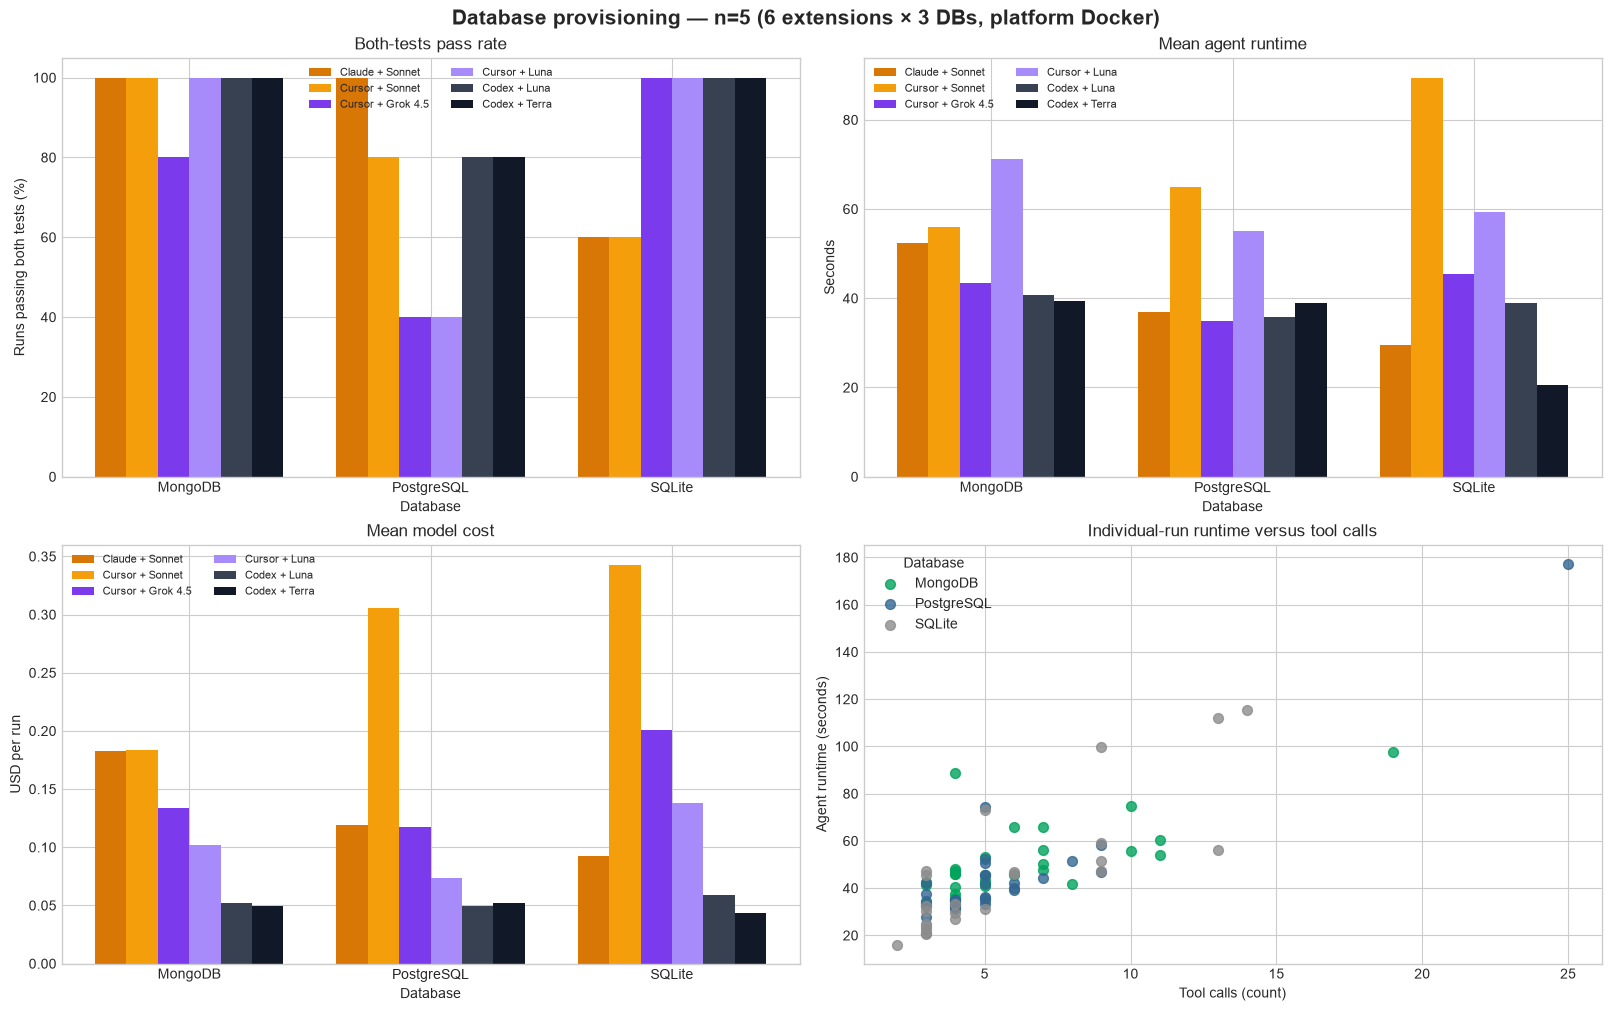

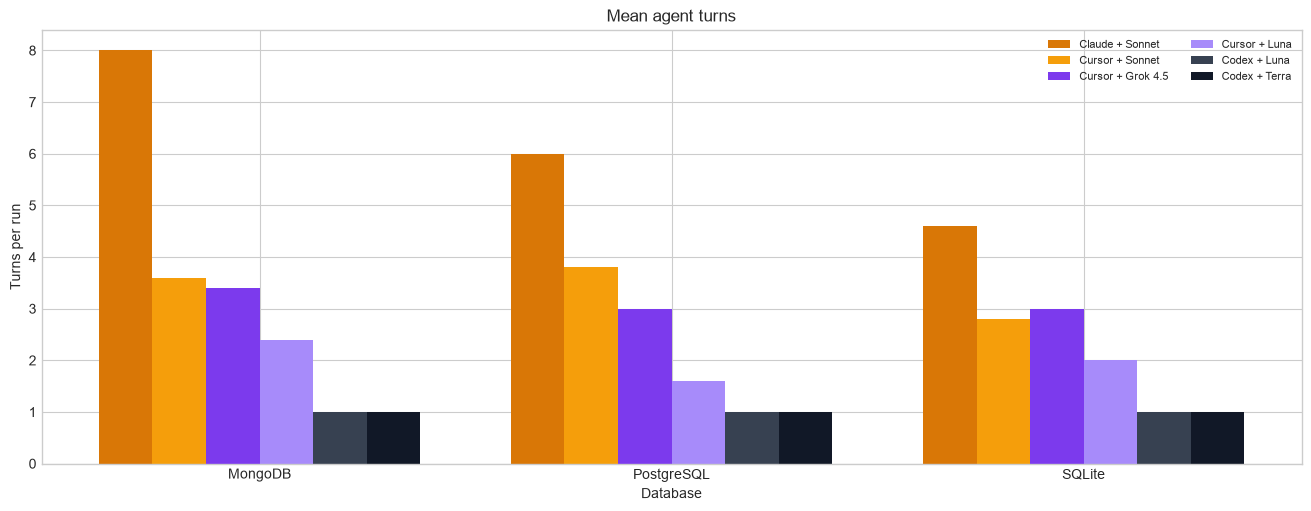

In [6]:
if not READY or summary.empty:
    print("Waiting for measurements.")
else:
    extensions = [name for name in EXTENSION_ORDER if name in set(summary["extension"])]
    fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
    fig.suptitle(
        "Database provisioning — n=5 (6 extensions × 3 DBs, platform Docker)",
        fontsize=15,
        fontweight="bold",
    )
    x = np.arange(len(DATABASE_ORDER))
    width = 0.13

    def grouped_bars(ax, column, title, ylabel, percent=False):
        for index, extension in enumerate(extensions):
            subset = (
                summary[summary["extension"] == extension]
                .set_index("database")
                .reindex(DATABASE_ORDER)
            )
            ax.bar(
                x + (index - (len(extensions) - 1) / 2) * width,
                subset[column].fillna(0),
                width=width,
                label=DISPLAY_NAMES.get(extension, extension),
                color=COLORS.get(extension, "#6B7280"),
            )
        ax.set_title(title)
        ax.set_xlabel("Database")
        ax.set_ylabel(ylabel)
        ax.set_xticks(x, [DISPLAY_NAMES[name] for name in DATABASE_ORDER])
        if percent:
            ax.set_ylim(0, 105)
        ax.legend(frameon=False, fontsize=8, ncol=2)

    grouped_bars(axes[0, 0], "pass_rate_pct", "Both-tests pass rate", "Runs passing both tests (%)", percent=True)
    grouped_bars(axes[0, 1], "runtime_mean_s", "Mean agent runtime", "Seconds")
    grouped_bars(axes[1, 0], "cost_mean_usd", "Mean model cost", "USD per run")

    for database in DATABASE_ORDER:
        subset = runs[runs["database"] == database]
        axes[1, 1].scatter(
            subset["tool_calls_total"],
            subset["runtime_s"],
            label=DISPLAY_NAMES[database],
            color=COLORS[database],
            s=50,
            alpha=0.8,
        )
    axes[1, 1].set_title("Individual-run runtime versus tool calls")
    axes[1, 1].set_xlabel("Tool calls (count)")
    axes[1, 1].set_ylabel("Agent runtime (seconds)")
    axes[1, 1].legend(title="Database", frameon=False)
    plt.show()

    fig, ax = plt.subplots(figsize=(13, 5), constrained_layout=True)
    grouped_bars(ax, "turns_mean", "Mean agent turns", "Turns per run")
    plt.show()


## Provisioning methods: attempted paths and inferred final method

Classify method evidence from ordered agent tool calls using the repository's
provisioning-method codebook. The query returns only method sequence numbers—not
commands, payloads, URIs, or credentials.

- **Attempted methods** count every acquisition/runtime path the agent executed.
  One run can contribute to multiple methods after fallback.
- **Inferred final method** is the latest method-specific provisioning action on
  runs that passed both tests. Failed runs are `none/unverified`.

This is a heuristic classification. `apt` followed by `docker run` is counted as
both attempted methods with `container` final. Standard-library Python
`sqlite3` is `built-in-library`, not an installation.

This run: MongoDB is almost all `container`. PostgreSQL is `container` when
both tests pass; readiness fails are `none/unverified`. SQLite is mostly
`built-in-library`, with Cursor + Sonnet Docker/libSQL as `container`.


,extension,database,repeat_idx,attempted_path,final_method,both_tests_passed
0,claude-sonnet,mongodb,0,container,container,True
1,claude-sonnet,mongodb,1,container,container,True
2,claude-sonnet,mongodb,2,container,container,True
3,claude-sonnet,mongodb,3,container,container,True
4,claude-sonnet,mongodb,4,container,container,True
...,...,...,...,...,...,...
40,codex-terra,sqlite,0,built-in-library,built-in-library,True
41,codex-terra,sqlite,1,built-in-library,built-in-library,True
42,codex-terra,sqlite,2,built-in-library,built-in-library,True
43,codex-terra,sqlite,3,built-in-library,built-in-library,True


Attempted method counts (a fallback run may appear more than once):


,database,attempted_methods,runs
0,mongodb,container,30
1,postgresql,container,28
2,postgresql,os-package-manager,1
3,postgresql,unknown,1
4,sqlite,built-in-library,22
5,sqlite,container,3
6,sqlite,preinstalled-runtime,1


Inferred final method counts:


,database,final_method,runs
0,mongodb,container,29
1,mongodb,none/unverified,1
2,postgresql,container,20
3,postgresql,none/unverified,9
4,postgresql,os-package-manager,1
5,sqlite,built-in-library,18
6,sqlite,container,2
7,sqlite,none/unverified,4
8,sqlite,preinstalled-runtime,1


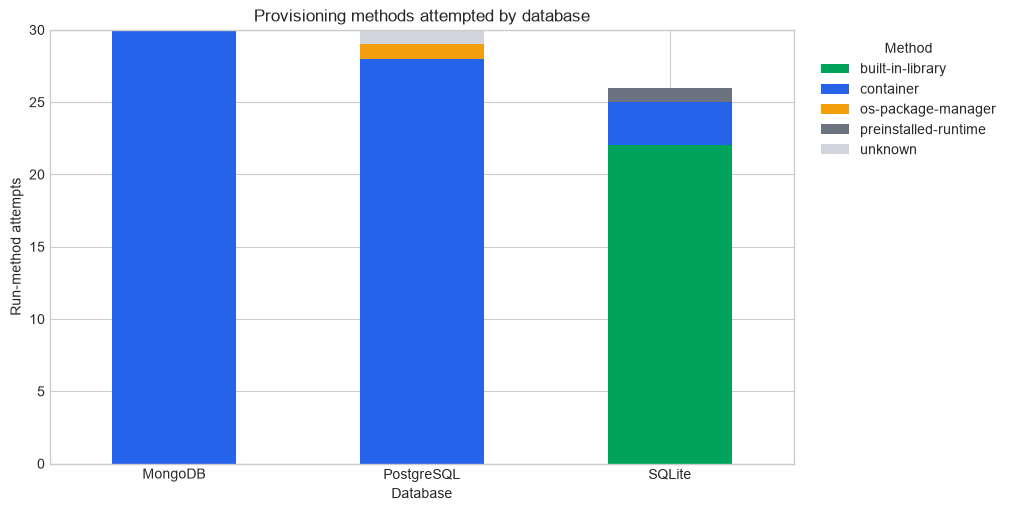

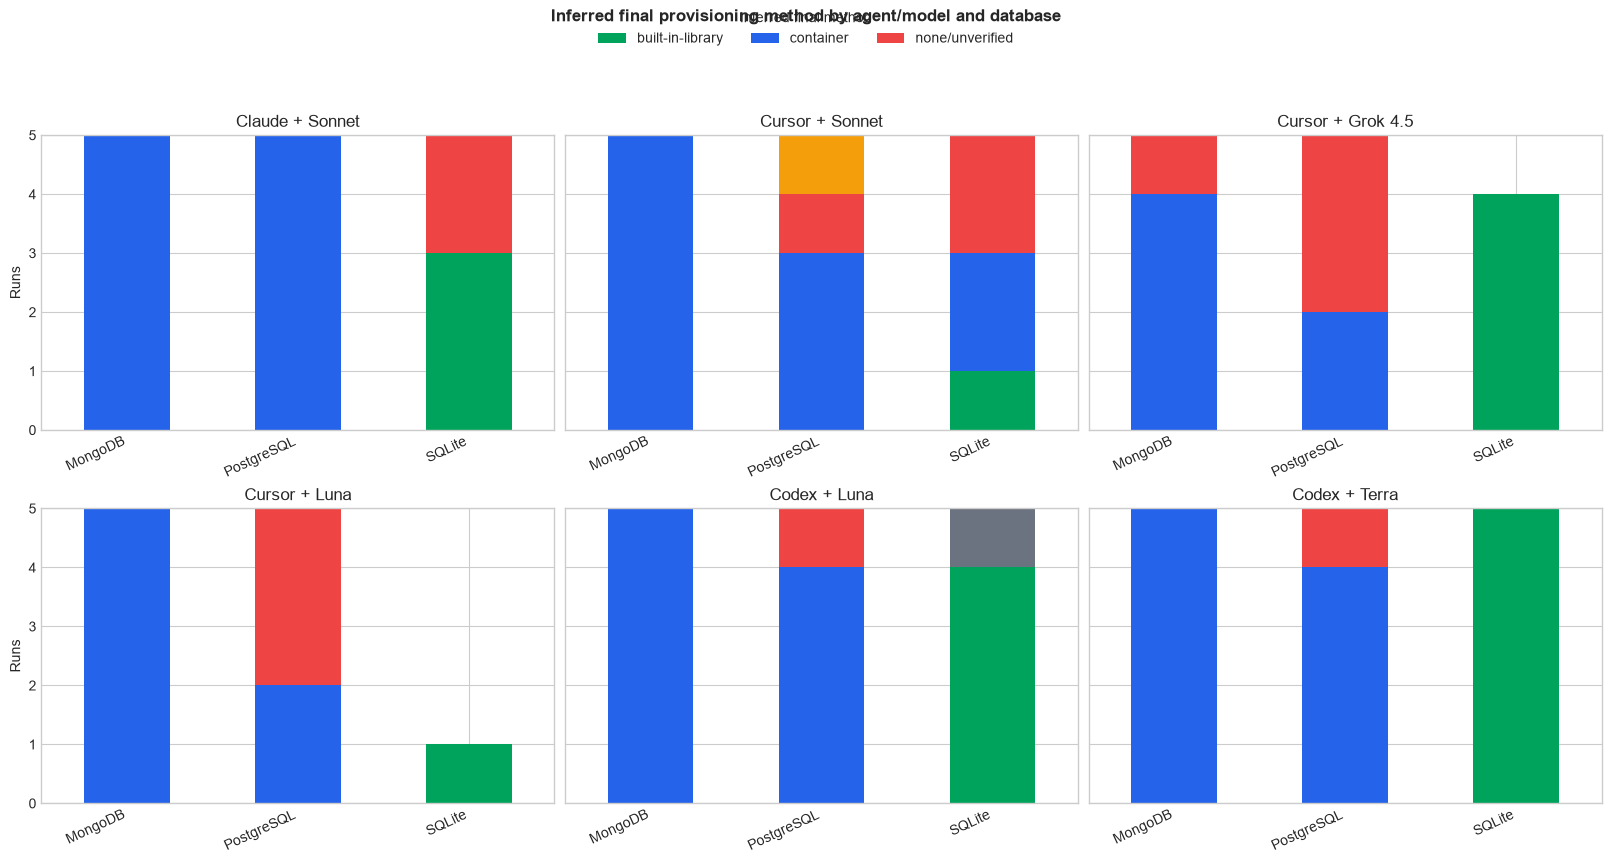

In [7]:
if not READY:
    method_runs = pd.DataFrame()
    print("Waiting for measurements.")
else:
    method_sql = f"""
    SELECT
        run_id,
        maxIf(toUInt64(coalesce(source_seq, 0)),
            positionCaseInsensitive(payload, 'docker run') > 0
            OR positionCaseInsensitive(payload, 'podman run') > 0
        ) AS container_seq,
        maxIf(toUInt64(coalesce(source_seq, 0)),
            (
                positionCaseInsensitive(payload, 'apt-get install') > 0
                OR positionCaseInsensitive(payload, 'apt install') > 0
                OR positionCaseInsensitive(payload, 'dnf install') > 0
                OR positionCaseInsensitive(payload, 'yum install') > 0
                OR positionCaseInsensitive(payload, 'apk add') > 0
                OR positionCaseInsensitive(payload, 'brew install') > 0
            )
            AND positionCaseInsensitive(payload, 'docker') = 0
            AND (
                (prompt_id = 'mongodb' AND positionCaseInsensitive(payload, 'mongo') > 0)
                OR (prompt_id = 'postgresql' AND positionCaseInsensitive(payload, 'postgres') > 0)
                OR (prompt_id = 'sqlite' AND positionCaseInsensitive(payload, 'sqlite') > 0)
            )
        ) AS os_package_manager_seq,
        maxIf(toUInt64(coalesce(source_seq, 0)),
            (
                positionCaseInsensitive(payload, 'curl ') > 0
                OR positionCaseInsensitive(payload, 'wget ') > 0
            )
            AND (
                positionCaseInsensitive(payload, '.tgz') > 0
                OR positionCaseInsensitive(payload, '.tar.gz') > 0
                OR positionCaseInsensitive(payload, '.zip') > 0
            )
            AND (
                (prompt_id = 'mongodb' AND positionCaseInsensitive(payload, 'mongo') > 0)
                OR (prompt_id = 'postgresql' AND positionCaseInsensitive(payload, 'postgres') > 0)
                OR (prompt_id = 'sqlite' AND positionCaseInsensitive(payload, 'sqlite') > 0)
            )
        ) AS official_binary_archive_seq,
        maxIf(toUInt64(coalesce(source_seq, 0)),
            (
                positionCaseInsensitive(payload, 'pip install') > 0
                OR positionCaseInsensitive(payload, 'pip3 install') > 0
                OR positionCaseInsensitive(payload, 'npm install') > 0
                OR positionCaseInsensitive(payload, 'npm add') > 0
            )
            AND (
                (prompt_id = 'mongodb' AND positionCaseInsensitive(payload, 'mongo') > 0)
                OR (prompt_id = 'postgresql' AND positionCaseInsensitive(payload, 'postgres') > 0)
                OR (prompt_id = 'sqlite' AND (
                    positionCaseInsensitive(payload, 'sqlite') > 0
                    OR positionCaseInsensitive(payload, 'libsql') > 0
                    OR positionCaseInsensitive(payload, 'sqld') > 0
                ))
            )
        ) AS language_package_runtime_seq,
        maxIf(toUInt64(coalesce(source_seq, 0)),
            prompt_id = 'sqlite'
            AND (
                positionCaseInsensitive(payload, 'import sqlite3') > 0
                OR positionCaseInsensitive(payload, 'from sqlite3') > 0
            )
        ) AS built_in_library_seq,
        maxIf(toUInt64(coalesce(source_seq, 0)),
            (
                (prompt_id = 'mongodb' AND (
                    positionCaseInsensitive(payload, ' mongod ') > 0
                    OR positionCaseInsensitive(payload, 'systemctl start mongod') > 0
                ))
                OR (prompt_id = 'postgresql' AND (
                    positionCaseInsensitive(payload, 'pg_ctl') > 0
                    OR positionCaseInsensitive(payload, 'systemctl start postgres') > 0
                ))
                OR (prompt_id = 'sqlite' AND positionCaseInsensitive(payload, 'sqlite3 ') > 0)
            )
        ) AS preinstalled_runtime_seq
    FROM events
    WHERE run_request_id = '{RUN_REQUEST_ID}'
      AND kind = 'tool_call'
      AND coalesce(assertion_role, 'primary') = 'primary'
    GROUP BY run_id
    """
    method_evidence = ax_query(method_sql)
    sequence_columns = {
        "container": "container_seq",
        "os-package-manager": "os_package_manager_seq",
        "official-binary-archive": "official_binary_archive_seq",
        "language-package-runtime": "language_package_runtime_seq",
        "built-in-library": "built_in_library_seq",
        "preinstalled-runtime": "preinstalled_runtime_seq",
    }
    if method_evidence.empty:
        method_evidence = pd.DataFrame(columns=["run_id", *sequence_columns.values()])
    for column in sequence_columns.values():
        if column not in method_evidence.columns:
            method_evidence[column] = 0
        method_evidence[column] = pd.to_numeric(method_evidence[column], errors="coerce").fillna(0)

    method_runs = runs.merge(method_evidence, on="run_id", how="left")
    for column in sequence_columns.values():
        method_runs[column] = pd.to_numeric(method_runs[column], errors="coerce").fillna(0)

    def _seq(row, column):
        value = row.get(column, 0)
        if value is None or (isinstance(value, float) and np.isnan(value)) or pd.isna(value):
            return 0
        return int(value)

    def classify_methods(row):
        ordered = [
            (method, _seq(row, column))
            for method, column in sequence_columns.items()
            if _seq(row, column) > 0
        ]
        acquisition_methods = {
            "container",
            "os-package-manager",
            "official-binary-archive",
            "language-package-runtime",
            "built-in-library",
        }
        # Starting software installed by apt/npm is part of that install path,
        # not a separate preinstalled-runtime method.
        if any(method in acquisition_methods for method, _ in ordered):
            ordered = [item for item in ordered if item[0] != "preinstalled-runtime"]
        ordered.sort(key=lambda item: item[1])
        attempted = [method for method, _ in ordered] or ["unknown"]
        passed = bool(row.get("both_tests_passed") is True or row.get("both_tests_passed") == 1)
        final = attempted[-1] if passed else "none/unverified"
        return attempted, final

    classified = method_runs.apply(classify_methods, axis=1)
    method_runs["attempted_methods"] = [item[0] for item in classified]
    method_runs["final_method"] = [item[1] for item in classified]
    method_runs["attempted_path"] = method_runs["attempted_methods"].str.join(" → ")

    method_display = method_runs[
        ["extension", "database", "repeat_idx", "attempted_path", "final_method", "both_tests_passed"]
    ].sort_values(["database", "extension", "repeat_idx"])
    display(method_display)

    attempted = method_runs[["run_id", "database", "extension", "attempted_methods"]].explode("attempted_methods")
    attempted_counts = (
        attempted.groupby(["database", "attempted_methods"], observed=True)
        .size()
        .rename("runs")
        .reset_index()
    )
    final_counts = (
        method_runs.groupby(["database", "final_method"], observed=True)
        .size()
        .rename("runs")
        .reset_index()
    )
    print("Attempted method counts (a fallback run may appear more than once):")
    display(attempted_counts)
    print("Inferred final method counts:")
    display(final_counts)

    method_colors = {
        "container": "#2563EB",
        "os-package-manager": "#F59E0B",
        "official-binary-archive": "#DC2626",
        "language-package-runtime": "#7C3AED",
        "built-in-library": "#00A35C",
        "preinstalled-runtime": "#6B7280",
        "unknown": "#D1D5DB",
        "none/unverified": "#EF4444",
    }

    attempted_pivot = attempted_counts.pivot(
        index="database", columns="attempted_methods", values="runs"
    ).fillna(0).reindex(DATABASE_ORDER)
    fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
    attempted_pivot.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=[method_colors.get(column, "#9CA3AF") for column in attempted_pivot.columns],
    )
    ax.set_title("Provisioning methods attempted by database")
    ax.set_xlabel("Database")
    ax.set_ylabel("Run-method attempts")
    ax.set_xticklabels([DISPLAY_NAMES[name] for name in DATABASE_ORDER], rotation=0)
    ax.legend(title="Method", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.show()

    present_extensions = [name for name in EXTENSION_ORDER if name in set(method_runs["extension"])]
    fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey=True, constrained_layout=True)
    for ax, extension in zip(axes.flat, present_extensions):
        subset = method_runs[method_runs["extension"] == extension]
        pivot = pd.crosstab(subset["database"], subset["final_method"]).reindex(DATABASE_ORDER, fill_value=0)
        pivot.plot(
            kind="bar",
            stacked=True,
            ax=ax,
            color=[method_colors.get(column, "#9CA3AF") for column in pivot.columns],
            legend=False,
        )
        ax.set_title(DISPLAY_NAMES.get(extension, extension))
        ax.set_xlabel("")
        ax.set_ylabel("Runs")
        ax.set_xticklabels([DISPLAY_NAMES[name] for name in DATABASE_ORDER], rotation=25, ha="right")
    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Inferred final method", loc="outside upper center", ncol=4, frameon=False)
    fig.suptitle("Inferred final provisioning method by agent/model and database", y=1.06, fontweight="bold")
    plt.show()


## Docker contract: published ports vs leftover host-network

Platform Docker uses stock bridge networking: `docker run -p` publishes to
sandbox localhost. The old guard (`Docker bridge networking is unavailable`
/ required `--network host`) is gone.

On this request: **0 guard hits** across finished runs. MongoDB 30/30
published `-p`; PostgreSQL 28/30; SQLite 3/25 (over-provisioned file DB).
Leftover `--network host` is rare and is agent habit, not a platform
requirement.


In [8]:
if not READY:
    print("Waiting for measurements.")
else:
    docker_sql = f"""
    SELECT
        run_id,
        countIf(positionCaseInsensitive(payload, 'docker run') > 0) AS docker_run_hits,
        countIf(position(payload, '27017:27017') > 0 OR position(payload, '5432:5432') > 0
             OR positionCaseInsensitive(payload, '--publish') > 0
             OR match(payload, '-p [0-9]+:[0-9]+')) AS publish_port_hits,
        countIf(positionCaseInsensitive(payload, '--network host') > 0
             OR positionCaseInsensitive(payload, '--network=host') > 0) AS host_network_hits,
        countIf(positionCaseInsensitive(payload, 'Docker bridge networking is unavailable') > 0) AS guard_hits
    FROM events
    WHERE run_request_id = '{RUN_REQUEST_ID}'
      AND kind = 'tool_call'
    GROUP BY run_id
    """
    docker_flags = ax_query(docker_sql)
    docker_runs = runs.merge(docker_flags, on="run_id", how="left")
    summary_flags = (
        docker_runs.groupby("database", observed=True)
        .agg(
            n=("run_id", "size"),
            docker_run=("docker_run_hits", lambda s: s.fillna(0).gt(0).sum()),
            published_port=("publish_port_hits", lambda s: s.fillna(0).gt(0).sum()),
            host_network=("host_network_hits", lambda s: s.fillna(0).gt(0).sum()),
            guard=("guard_hits", lambda s: s.fillna(0).gt(0).sum()),
        )
        .reindex(DATABASE_ORDER)
        .reset_index()
    )
    print("Runs with at least one matching tool-call (not event counts):")
    display(summary_flags)
    n_guard = int(docker_runs["guard_hits"].fillna(0).gt(0).sum())
    print(
        f"Guard hits across finished runs: {n_guard}/{len(docker_runs)}. "
        "Expected ~0 on this platform Docker contract."
    )
    leftover = docker_runs[docker_runs["host_network_hits"].fillna(0).gt(0)][
        ["extension", "database", "repeat_idx", "host_network_hits"]
    ].sort_values(["database", "extension", "repeat_idx"])
    if leftover.empty:
        print("No leftover --network host tool-calls.")
    else:
        leftover = leftover.copy()
        leftover["extension"] = leftover["extension"].map(DISPLAY_NAMES).fillna(leftover["extension"].astype(str))
        leftover["database"] = leftover["database"].map(DISPLAY_NAMES)
        print("Leftover --network host runs (habit, not the old wrapper):")
        display(leftover)


Runs with at least one matching tool-call (not event counts):


,database,n,docker_run,published_port,host_network,guard
0,mongodb,30,30,30,1,0
1,postgresql,30,28,28,2,0
2,sqlite,25,3,3,0,0


Guard hits across finished runs: 0/85. Expected ~0 on this platform Docker contract.
Leftover --network host runs (habit, not the old wrapper):


,extension,database,repeat_idx,host_network_hits
4,Claude + Sonnet,MongoDB,4,2.0
5,Claude + Sonnet,PostgreSQL,0,2.0
51,Cursor + Sonnet,PostgreSQL,1,2.0


## Efficiency views

MongoDB completion is near-ceiling, so a pass-rate Pareto frontier is not
informative there. PostgreSQL and SQLite are **not** at ceiling — read
pass-rate first, then these views among measured runs.

1. **Cost dot-and-whisker:** every measured run, median, and interquartile range;
   failed runs are red `×` markers rather than silently excluded.
2. **Runtime distribution:** horizontal boxplots plus every measured run.
3. **Efficiency rank heatmaps:** separate within-database ranks for runtime,
   cost, and turns. Rank 1 is most efficient.
4. **Pooled database boxplots:** these mix harnesses. SQLite's pooled sd is
   method mix; Postgres's pooled sd is one Cursor + Sonnet apt/`psql` trial (177s), not the
   same story.

Starved runs have no measurement rows. Reliability is reported separately from
efficiency. This run used ordinary `docker run -p` (0 guard hits); remaining
spread is harness and method mix, not a host-network retry tax.


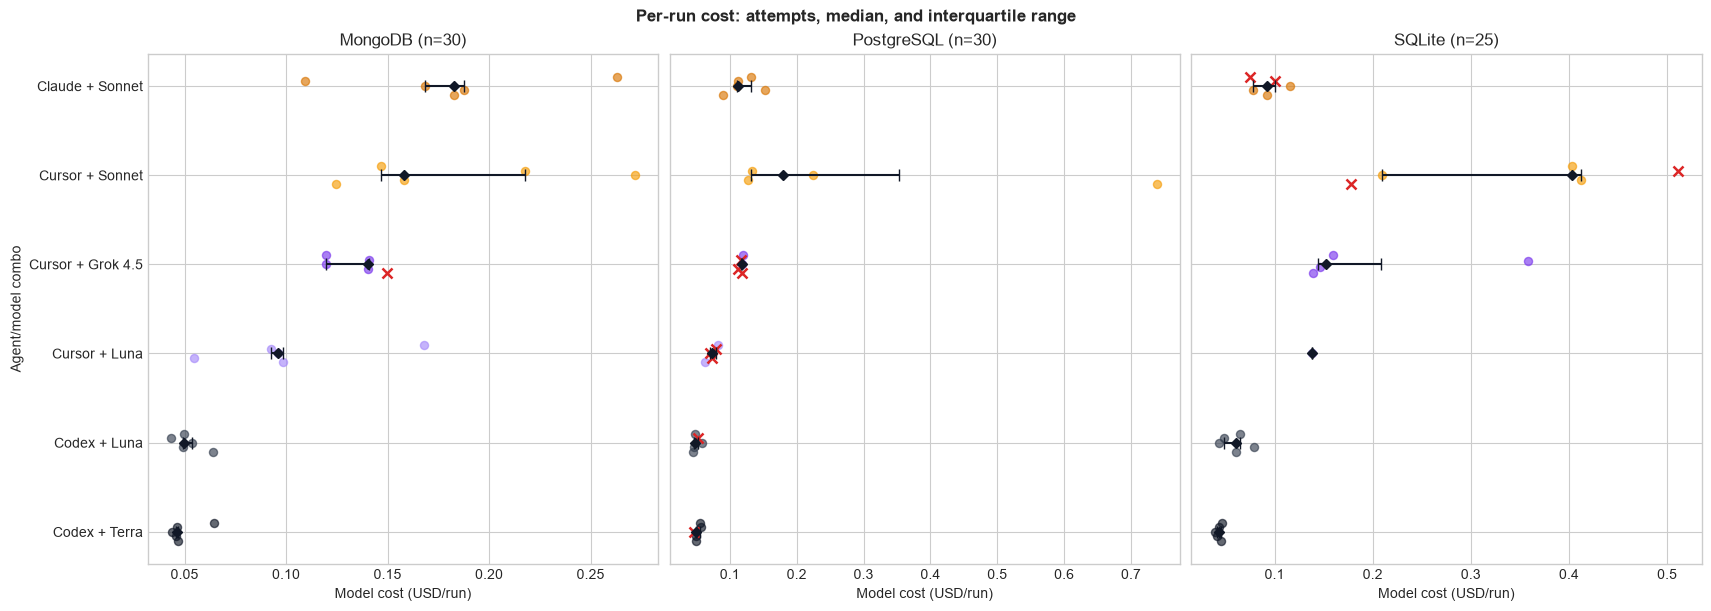

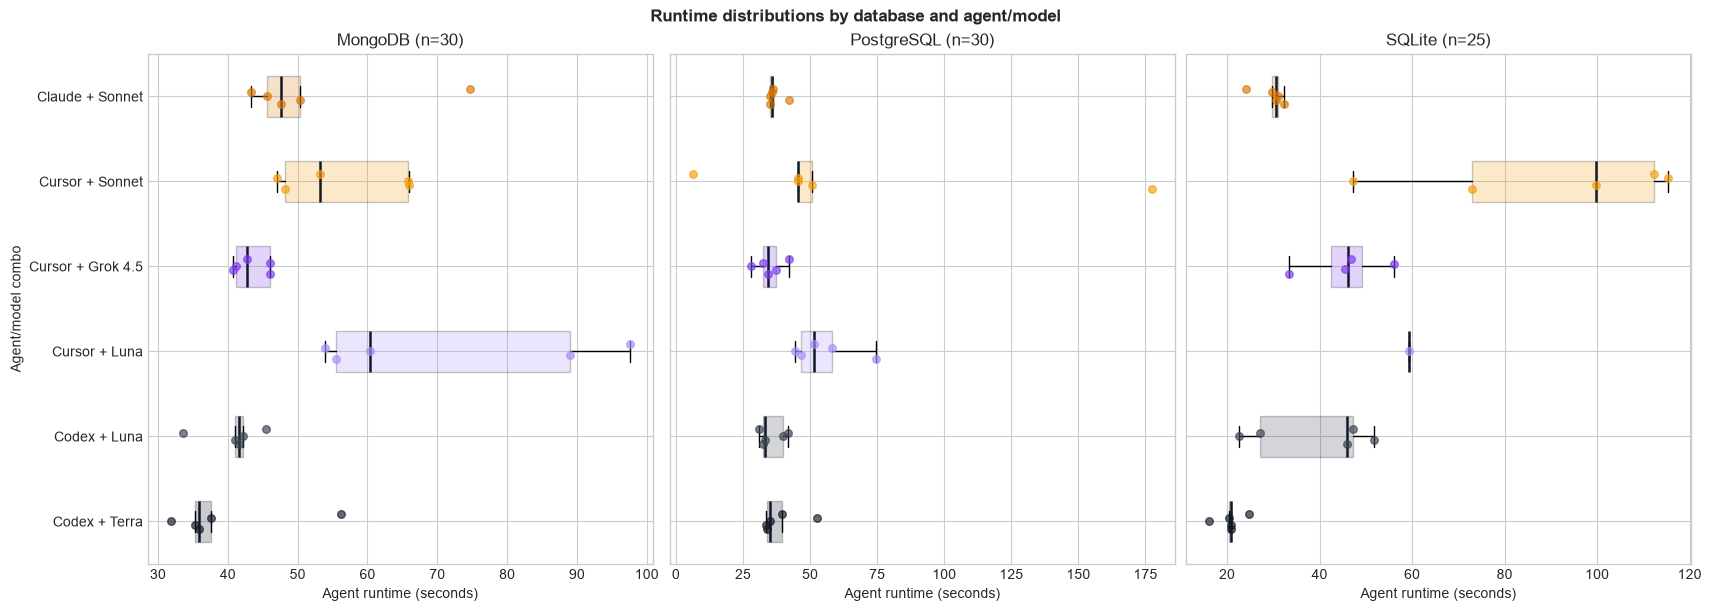

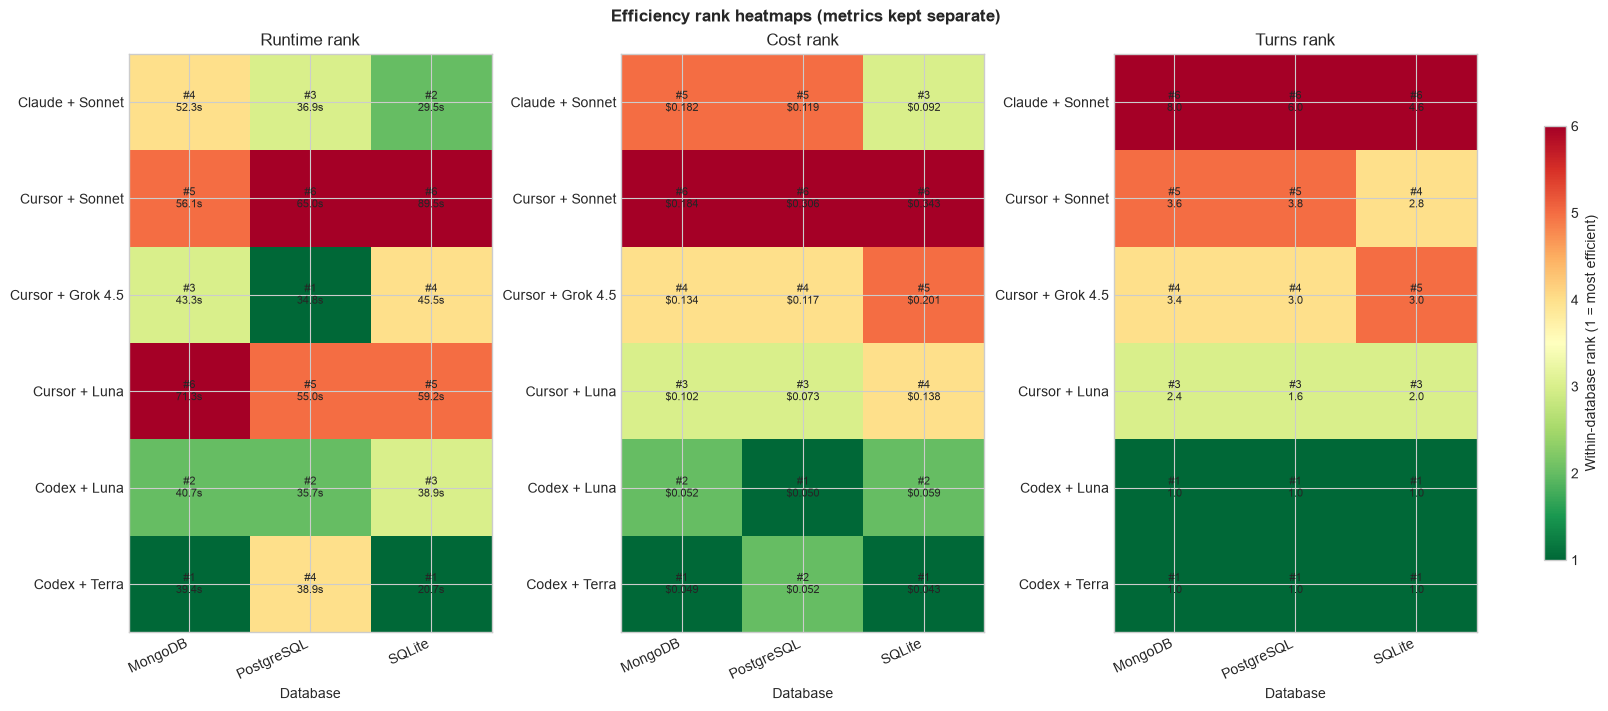

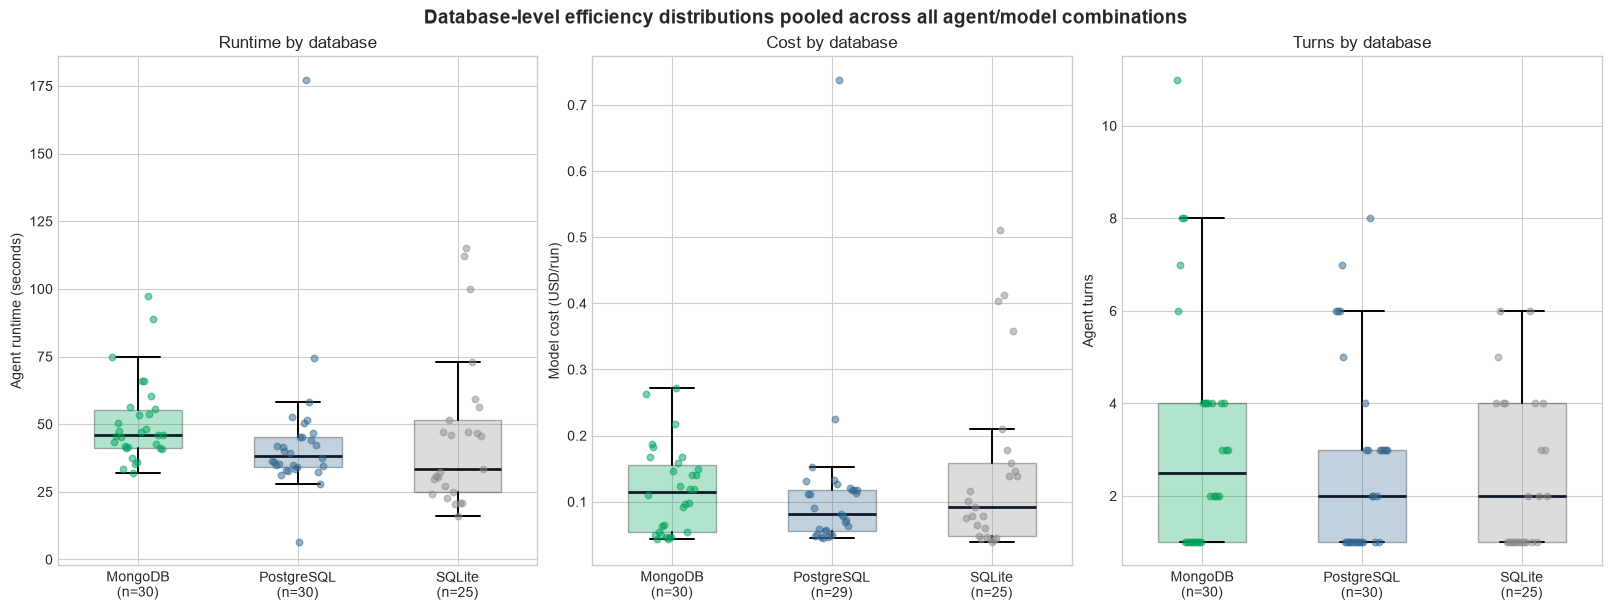

In [9]:
if not READY or summary.empty:
    print("Waiting for measurements.")
else:
    present_extensions = [name for name in EXTENSION_ORDER if name in set(runs["extension"])]
    extension_labels = [DISPLAY_NAMES.get(name, name) for name in present_extensions]
    y_positions = np.arange(len(present_extensions))

    # 1) Cost dot-and-whisker: individual attempts plus median and IQR.
    fig, axes = plt.subplots(1, 3, figsize=(17, 6), sharey=True, constrained_layout=True)
    for ax, database in zip(axes, DATABASE_ORDER):
        database_runs = runs[runs["database"] == database]
        for y_position, extension in zip(y_positions, present_extensions):
            subset = database_runs[database_runs["extension"] == extension].sort_values("repeat_idx")
            values = subset["cost_usd"].dropna().to_numpy(dtype=float)
            if not len(values):
                continue
            median = float(np.median(values))
            q1, q3 = np.quantile(values, [0.25, 0.75])
            jitter = np.linspace(-0.10, 0.10, len(subset)) if len(subset) > 1 else np.array([0.0])
            passed = subset["both_tests_passed"].to_numpy(dtype=bool)

            ax.scatter(
                subset.loc[passed, "cost_usd"],
                y_position + jitter[passed],
                color=COLORS.get(extension, "#6B7280"),
                alpha=0.65,
                s=34,
                zorder=2,
            )
            if (~passed).any():
                ax.scatter(
                    subset.loc[~passed, "cost_usd"],
                    y_position + jitter[~passed],
                    color="#DC2626",
                    marker="x",
                    linewidths=1.8,
                    s=52,
                    zorder=3,
                )
            ax.errorbar(
                median,
                y_position,
                xerr=np.array([[median - q1], [q3 - median]]),
                fmt="D",
                color="#111827",
                ecolor="#111827",
                capsize=4,
                markersize=5,
                zorder=4,
            )

        ax.set_title(f"{DISPLAY_NAMES[database]} (n={len(database_runs)})")
        ax.set_xlabel("Model cost (USD/run)")
        ax.set_yticks(y_positions, extension_labels)
        ax.invert_yaxis()
    axes[0].set_ylabel("Agent/model combo")
    fig.suptitle("Per-run cost: attempts, median, and interquartile range", fontweight="bold")
    plt.show()

    # 2) Runtime distribution: boxes show quartiles; dots preserve all n=3–5 runs.
    fig, axes = plt.subplots(1, 3, figsize=(17, 6), sharey=True, constrained_layout=True)
    for ax, database in zip(axes, DATABASE_ORDER):
        database_runs = runs[runs["database"] == database]
        distributions = []
        positions = []
        for y_position, extension in zip(y_positions, present_extensions):
            subset = database_runs[database_runs["extension"] == extension].sort_values("repeat_idx")
            values = subset["runtime_s"].dropna().to_numpy(dtype=float)
            if not len(values):
                continue
            distributions.append(values)
            positions.append(y_position)
            jitter = np.linspace(-0.09, 0.09, len(values)) if len(values) > 1 else np.array([0.0])
            ax.scatter(
                values,
                y_position + jitter,
                color=COLORS.get(extension, "#6B7280"),
                alpha=0.65,
                s=30,
                zorder=3,
            )
        if distributions:
            boxes = ax.boxplot(
                distributions,
                positions=positions,
                orientation="horizontal",
                widths=0.48,
                patch_artist=True,
                showfliers=False,
                medianprops={"color": "#111827", "linewidth": 1.8},
            )
            for patch, position in zip(boxes["boxes"], positions):
                extension = present_extensions[position]
                patch.set_facecolor(COLORS.get(extension, "#9CA3AF"))
                patch.set_alpha(0.22)
        ax.set_title(f"{DISPLAY_NAMES[database]} (n={len(database_runs)})")
        ax.set_xlabel("Agent runtime (seconds)")
        ax.set_yticks(y_positions, extension_labels)
        ax.invert_yaxis()
    axes[0].set_ylabel("Agent/model combo")
    fig.suptitle("Runtime distributions by database and agent/model", fontweight="bold")
    plt.show()

    # 3) Separate rank heatmaps avoid arbitrary weighting across unlike units.
    rank_metrics = [
        ("runtime_mean_s", "Runtime rank", "s"),
        ("cost_mean_usd", "Cost rank", "$"),
        ("turns_mean", "Turns rank", " turns"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(16, 7), constrained_layout=True)
    for ax, (metric, title, unit) in zip(axes, rank_metrics):
        ranked = summary[["extension", "database", metric]].copy()
        ranked["rank"] = ranked.groupby("database", observed=True)[metric].rank(method="min", ascending=True)
        value_pivot = ranked.pivot(index="extension", columns="database", values=metric).reindex(
            index=present_extensions, columns=DATABASE_ORDER
        )
        rank_pivot = ranked.pivot(index="extension", columns="database", values="rank").reindex(
            index=present_extensions, columns=DATABASE_ORDER
        )
        image = ax.imshow(
            rank_pivot.to_numpy(dtype=float),
            cmap="RdYlGn_r",
            vmin=1,
            vmax=len(present_extensions),
            aspect="auto",
        )
        for row_index, extension in enumerate(present_extensions):
            for column_index, database in enumerate(DATABASE_ORDER):
                rank = rank_pivot.loc[extension, database]
                value = value_pivot.loc[extension, database]
                if pd.isna(rank) or pd.isna(value):
                    annotation = "—"
                elif unit == "$":
                    annotation = f"#{int(rank)}\n${value:.3f}"
                elif unit == "s":
                    annotation = f"#{int(rank)}\n{value:.1f}s"
                else:
                    annotation = f"#{int(rank)}\n{value:.1f}"
                ax.text(column_index, row_index, annotation, ha="center", va="center", fontsize=8)
        ax.set_title(title)
        ax.set_xticks(np.arange(len(DATABASE_ORDER)), [DISPLAY_NAMES[name] for name in DATABASE_ORDER], rotation=25, ha="right")
        ax.set_yticks(np.arange(len(present_extensions)), extension_labels)
        ax.set_xlabel("Database")
    fig.colorbar(image, ax=axes, label="Within-database rank (1 = most efficient)", shrink=0.75)
    fig.suptitle("Efficiency rank heatmaps (metrics kept separate)", fontweight="bold")
    plt.show()

    # 4) Pool all agent/model combinations to compare database-level distributions.
    pooled_metrics = [
        ("runtime_s", "Agent runtime (seconds)", "Runtime by database"),
        ("cost_usd", "Model cost (USD/run)", "Cost by database"),
        ("num_turns", "Agent turns", "Turns by database"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(16, 6), constrained_layout=True)
    database_positions = np.arange(1, len(DATABASE_ORDER) + 1)
    for ax, (metric, y_label, title) in zip(axes, pooled_metrics):
        distributions = [
            runs.loc[runs["database"] == database, metric].dropna().to_numpy(dtype=float)
            for database in DATABASE_ORDER
        ]
        boxes = ax.boxplot(
            distributions,
            positions=database_positions,
            widths=0.55,
            patch_artist=True,
            showfliers=False,
            medianprops={"color": "#111827", "linewidth": 2},
            whiskerprops={"linewidth": 1.4},
            capprops={"linewidth": 1.4},
        )
        for patch, database in zip(boxes["boxes"], DATABASE_ORDER):
            patch.set_facecolor(COLORS[database])
            patch.set_alpha(0.30)
        for position, database, values in zip(database_positions, DATABASE_ORDER, distributions):
            jitter = np.linspace(-0.16, 0.16, len(values)) if len(values) > 1 else np.array([0.0])
            ax.scatter(
                position + jitter,
                values,
                color=COLORS[database],
                alpha=0.50,
                s=22,
                zorder=3,
            )
        labels = [
            f"{DISPLAY_NAMES[database]}\n(n={len(values)})"
            for database, values in zip(DATABASE_ORDER, distributions)
        ]
        ax.set_xticks(database_positions, labels)
        ax.set_ylabel(y_label)
        ax.set_title(title)
    fig.suptitle(
        "Database-level efficiency distributions pooled across all agent/model combinations",
        fontsize=14,
        fontweight="bold",
    )
    plt.show()


## Variant pruning: same model across harnesses

The design's prune rule: if a **model behaves the same across harnesses**, drop
one combo before scale. The two overlapping models in this matrix are:

- Sonnet 5: Claude Code vs Cursor
- GPT-5.6 Luna: Codex vs Cursor

"Same" here is operational, not statistical proof. With n=5, Wilson intervals
are wide. Treat a pair as **prunable** when pass rates overlap, cost/runtime
are the same order of magnitude, and the Mongo vs Postgres vs SQLite *pattern*
matches (not just the average). Keep both if one harness fails a database the
other consistently provisions, or if cost differs enough to change a Pareto
read.

Cursor + Grok and Codex + Terra have no same-model pair; they stay unless this
n=5 shows they add no extra ranking information.

On this request, do not prune either pair. Cursor + Sonnet is 2–4× Claude's
cost on Postgres/SQLite and has a harness model-id error. Cursor + Luna
Postgres is 2/5 vs Codex 4/5, and Cursor SQLite is almost unmeasured.
Cursor + Grok stays: it is the Postgres failure mode we would otherwise lose.


In [10]:
if not READY:
    print("Waiting for measurements.")
else:
    rows = []
    for left, right, label in HARNESS_PAIRS:
        for database in DATABASE_ORDER:
            a = summary[(summary["extension"] == left) & (summary["database"] == database)]
            b = summary[(summary["extension"] == right) & (summary["database"] == database)]
            if a.empty or b.empty:
                rows.append(
                    {
                        "pair": label,
                        "database": DISPLAY_NAMES[database],
                        "note": "missing cell",
                    }
                )
                continue
            a, b = a.iloc[0], b.iloc[0]
            overlap = a.pass_rate_hi >= b.pass_rate_lo and b.pass_rate_hi >= a.pass_rate_lo
            rows.append(
                {
                    "pair": label,
                    "database": DISPLAY_NAMES[database],
                    "left": DISPLAY_NAMES[left],
                    "right": DISPLAY_NAMES[right],
                    "left_n": int(a.runs),
                    "right_n": int(b.runs),
                    "left_pass_pct": a.pass_rate_pct,
                    "right_pass_pct": b.pass_rate_pct,
                    "ci_overlap": overlap,
                    "pass_pp_diff": (a.pass_rate - b.pass_rate) * 100,
                    "runtime_ratio": a.runtime_mean_s / b.runtime_mean_s if b.runtime_mean_s else np.nan,
                    "cost_ratio": a.cost_mean_usd / b.cost_mean_usd if b.cost_mean_usd else np.nan,
                    "left_cost": a.cost_mean_usd,
                    "right_cost": b.cost_mean_usd,
                }
            )
    prune = pd.DataFrame(rows)
    display(prune.round(3))

    print("Pair-level prune hint (overlapping CIs are necessary, not proof of equivalence):")
    for left, right, label in HARNESS_PAIRS:
        subset = prune[prune["pair"] == label]
        if subset.empty or "ci_overlap" not in subset:
            print(f"- {label}: not enough cells")
            continue

        complete_cells = (subset[["left_n", "right_n"]] >= 5).all().all()
        close_completion = subset["pass_pp_diff"].abs().le(10).all()
        comparable_cost = subset["cost_ratio"].between(0.5, 2.0).all()
        prune_supported = (
            complete_cells
            and subset["ci_overlap"].all()
            and close_completion
            and comparable_cost
        )

        if prune_supported:
            cheaper = left if subset["left_cost"].mean() <= subset["right_cost"].mean() else right
            drop = right if cheaper == left else left
            print(
                f"- {label}: provisional prune candidate; completion differs by no more "
                f"than 10pp in each database. Keep {DISPLAY_NAMES[cheaper]} and "
                f"consider dropping {DISPLAY_NAMES[drop]}."
            )
        else:
            reasons = []
            if not complete_cells:
                reasons.append("one or more cells have fewer than five measured runs")
            if not close_completion:
                reasons.append("completion differs by more than 10pp")
            if not comparable_cost:
                reasons.append("mean cost differs by more than 2x")
            print(
                f"- {label}: do not prune from n=5 alone (" + "; ".join(reasons) + ")."
            )


,pair,database,left,right,left_n,right_n,left_pass_pct,right_pass_pct,ci_overlap,pass_pp_diff,runtime_ratio,cost_ratio,left_cost,right_cost
0,Sonnet across Claude vs Cursor,MongoDB,Claude + Sonnet,Cursor + Sonnet,5,5,100.0,100.0,True,0.0,0.933,0.992,0.182,0.184
1,Sonnet across Claude vs Cursor,PostgreSQL,Claude + Sonnet,Cursor + Sonnet,5,5,100.0,80.0,True,20.0,0.567,0.391,0.119,0.306
2,Sonnet across Claude vs Cursor,SQLite,Claude + Sonnet,Cursor + Sonnet,5,5,60.0,60.0,True,0.0,0.330,0.269,0.092,0.343
3,Luna across Codex vs Cursor,MongoDB,Codex + Luna,Cursor + Luna,5,5,100.0,100.0,True,0.0,0.572,0.510,0.052,0.102
4,Luna across Codex vs Cursor,PostgreSQL,Codex + Luna,Cursor + Luna,5,5,80.0,40.0,True,40.0,0.649,0.678,0.050,0.073
5,Luna across Codex vs Cursor,SQLite,Codex + Luna,Cursor + Luna,5,1,100.0,100.0,True,0.0,0.657,0.428,0.059,0.138


Pair-level prune hint (overlapping CIs are necessary, not proof of equivalence):
- Sonnet across Claude vs Cursor: do not prune from n=5 alone (completion differs by more than 10pp; mean cost differs by more than 2x).
- Luna across Codex vs Cursor: do not prune from n=5 alone (one or more cells have fewer than five measured runs; completion differs by more than 10pp; mean cost differs by more than 2x).


## Sample size for the scale run

n=5 is for pruning, not ranking. Scale needs enough repeats to tell databases
apart on **completion** and to put a usable interval on **cost/time**.

Rules of thumb used below (95% CI, 80% power where noted):

- Single-cell pass-rate CI half-width ≈ 1.96 √(p(1-p)/n). At p=0.8, n=10 → ±25pp,
  n=20 → ±18pp, n=30 → ±14pp. n=10 cannot distinguish 70% from 90% in one cell.
- Two-proportion n per group to detect a 20pp gap (0.70 vs 0.90) is about 30.
  A 10pp gap needs ~n=120 and is not worth buying at this task's cost.

On this request MongoDB is already near-ceiling and PostgreSQL is not
(Cursor + Grok / Luna at 40%). Use **n=20** if Postgres/SQLite completion is
still in scope; **n=10** is enough only for Mongo-only efficiency among
successes.


In [11]:
def n_for_margin(p, margin, z=1.96):
    if margin <= 0:
        return np.inf
    return int(np.ceil((z**2 * p * (1 - p)) / margin**2))


def n_two_proportion(p1, p2, z_alpha=1.96, z_power=0.8416):
    delta = abs(p1 - p2)
    if delta == 0:
        return np.inf
    return int(
        np.ceil(
            ((z_alpha + z_power) ** 2 * (p1 * (1 - p1) + p2 * (1 - p2))) / delta**2
        )
    )


if not READY:
    print("Waiting for measurements. Sample-size table will use observed pass rates.")
    p_hat = 0.8
else:
    p_hat = float(runs["both_tests_passed"].mean())
    print(f"Observed overall pass rate on finished runs: {p_hat:.1%}")

ci_width = pd.DataFrame(
    {
        "n_per_variant": [10, 20, 30],
        "ci_halfwidth_pp_at_observed_p": [
            196 * np.sqrt(p_hat * (1 - p_hat) / n) for n in (10, 20, 30)
        ],
    }
)
power = pd.DataFrame(
    [
        {"contrast": "70% vs 90% (20pp)", "n_per_group": n_two_proportion(0.70, 0.90)},
        {"contrast": "80% vs 90% (10pp)", "n_per_group": n_two_proportion(0.80, 0.90)},
        {"contrast": "60% vs 90% (30pp)", "n_per_group": n_two_proportion(0.60, 0.90)},
        {"contrast": "CI ±10pp at p=0.8", "n_per_group": n_for_margin(0.8, 0.10)},
        {"contrast": "CI ±15pp at p=0.8", "n_per_group": n_for_margin(0.8, 0.15)},
    ]
)
display(ci_width.round(1))
display(power)
if READY:
    mongo_p = float(runs.loc[runs["database"] == "mongodb", "both_tests_passed"].mean())
    pg_p = float(runs.loc[runs["database"] == "postgresql", "both_tests_passed"].mean())
    sqlite_p = float(runs.loc[runs["database"] == "sqlite", "both_tests_passed"].mean())
    print(
        f"Finished-row pass rates: MongoDB {mongo_p:.0%}, PostgreSQL {pg_p:.0%}, "
        f"SQLite {sqlite_p:.0%}. Mongo is near-ceiling; Postgres is the completion "
        "gap. Suggested scale N: 20/variant while Postgres/SQLite completion is in "
        "scope, or 10/variant for Mongo-only efficiency CIs."
    )
else:
    print(
        "Suggested scale N: 20/variant after pruning, or 10/variant if Mongo is "
        "already near-ceiling and the remaining question is efficiency."
    )


Observed overall pass rate on finished runs: 83.5%


,n_per_variant,ci_halfwidth_pp_at_observed_p
0,10,23.0
1,20,16.3
2,30,13.3


,contrast,n_per_group
0,70% vs 90% (20pp),59
1,80% vs 90% (10pp),197
2,60% vs 90% (30pp),29
3,CI ±10pp at p=0.8,62
4,CI ±15pp at p=0.8,28


Finished-row pass rates: MongoDB 97%, PostgreSQL 70%, SQLite 84%. Mongo is near-ceiling; Postgres is the completion gap. Suggested scale N: 20/variant while Postgres/SQLite completion is in scope, or 10/variant for Mongo-only efficiency CIs.


## Cost of this run and scale estimates

Scale cost ≈ (mean USD per finished run in the kept extensions) × variants × n.
Starved/harness failures are excluded from the mean so we do not treat missing
rows as free. Add ~15% contingency for retries.

Cursor + Sonnet is about 2× the overall mean $/run, so dropping it is the
largest cost lever. This n=5 does **not** show the duplicate harnesses as
interchangeable, so the keep-all n=20 estimate is the honest working number
unless we prune for cost or reliability rather than equivalence.


In [12]:
if not READY:
    print("Waiting for measurements.")
else:
    cost_by_extension = (
        runs.groupby("extension", observed=True)
        .agg(
            n=("run_id", "size"),
            cost_total=("cost_usd", "sum"),
            cost_mean=("cost_usd", "mean"),
            runtime_mean_s=("runtime_s", "mean"),
        )
        .reindex([name for name in EXTENSION_ORDER if name in set(runs["extension"])])
        .reset_index()
    )
    cost_by_extension["label"] = cost_by_extension["extension"].map(DISPLAY_NAMES)
    display(cost_by_extension.round(3))

    this_run_cost = float(runs["cost_usd"].sum())
    mean_all = float(runs["cost_usd"].mean())
    print(f"This request, finished runs only: ${this_run_cost:.2f} across {len(runs)} rows")
    print(f"Mean $/run: ${mean_all:.3f}")

    keep_all = EXTENSION_ORDER
    drop_cursor_sonnet = [e for e in EXTENSION_ORDER if e != "cursor-sonnet"]
    drop_cursor_luna = [e for e in EXTENSION_ORDER if e != "cursor-luna"]
    drop_both_dupes = [e for e in EXTENSION_ORDER if e not in {"cursor-sonnet", "cursor-luna"}]

    def scenario_cost(extensions, n, label):
        subset = runs[runs["extension"].isin(extensions)]
        if subset.empty:
            return None
        mean = float(subset["cost_usd"].mean())
        variants = len(extensions) * len(DATABASE_ORDER)
        trials = variants * n
        base = mean * trials
        return {
            "scenario": label,
            "extensions": len(extensions),
            "variants": variants,
            "n": n,
            "trials": trials,
            "mean_usd_per_run": mean,
            "estimated_usd": base,
            "with_15pct_contingency": base * 1.15,
        }

    scenarios = []
    for n in (10, 20, 30):
        scenarios.append(scenario_cost(keep_all, n, f"Keep all 6 combos, n={n}"))
        scenarios.append(scenario_cost(drop_cursor_sonnet, n, f"Drop Cursor+Sonnet, n={n}"))
        scenarios.append(scenario_cost(drop_cursor_luna, n, f"Drop Cursor+Luna, n={n}"))
        scenarios.append(scenario_cost(drop_both_dupes, n, f"Drop both duplicate-model harnesses, n={n}"))
    estimate = pd.DataFrame([row for row in scenarios if row])
    display(estimate.round(2))

    keep20 = scenario_cost(keep_all, 20, "keep-all")
    drop20 = scenario_cost(drop_both_dupes, 20, "drop-dupes")
    drop_sonnet20 = scenario_cost(drop_cursor_sonnet, 20, "drop-cursor-sonnet")
    if keep20 and drop20 and drop_sonnet20:
        print(
            "This n=5 does not treat the duplicate harnesses as interchangeable. "
            f"Keep-all n=20 ≈ ${keep20['estimated_usd']:.0f} "
            f"(${keep20['with_15pct_contingency']:.0f} with contingency). "
            f"Drop Cursor+Sonnet only ≈ ${drop_sonnet20['estimated_usd']:.0f}. "
            f"Drop both duplicate harnesses ≈ ${drop20['estimated_usd']:.0f}."
        )


,extension,n,cost_total,cost_mean,runtime_mean_s,label
0,claude-sonnet,15,1.971,0.131,39.562,Claude + Sonnet
1,cursor-sonnet,15,3.857,0.276,70.181,Cursor + Sonnet
2,cursor-grok,14,2.057,0.147,40.915,Cursor + Grok 4.5
3,cursor-luna,11,1.015,0.092,62.790,Cursor + Luna
4,codex-luna,15,0.806,0.054,38.449,Codex + Luna
5,codex-terra,15,0.721,0.048,32.972,Codex + Terra


This request, finished runs only: $10.43 across 85 rows
Mean $/run: $0.124


,scenario,extensions,variants,n,trials,mean_usd_per_run,estimated_usd,with_15pct_contingency
0,"Keep all 6 combos, n=10",6,18,10,180,0.12,22.35,25.70
1,"Drop Cursor+Sonnet, n=10",5,15,10,150,0.09,14.08,16.19
2,"Drop Cursor+Luna, n=10",5,15,10,150,0.13,19.34,22.24
3,"Drop both duplicate-model harnesses, n=10",4,12,10,120,0.09,11.30,12.99
4,"Keep all 6 combos, n=20",6,18,20,360,0.12,44.69,51.39
5,"Drop Cursor+Sonnet, n=20",5,15,20,300,0.09,28.16,32.38
6,"Drop Cursor+Luna, n=20",5,15,20,300,0.13,38.68,44.49
7,"Drop both duplicate-model harnesses, n=20",4,12,20,240,0.09,22.60,25.99
8,"Keep all 6 combos, n=30",6,18,30,540,0.12,67.04,77.09
9,"Drop Cursor+Sonnet, n=30",5,15,30,450,0.09,42.24,48.57


This n=5 does not treat the duplicate harnesses as interchangeable. Keep-all n=20 ≈ $45 ($51 with contingency). Drop Cursor+Sonnet only ≈ $28. Drop both duplicate harnesses ≈ $23.


## Why SQLite runtime spread looks high

Pooled SQLite runtime on this request is **mean 45.3s, sd 28.0s** (n=25 finished;
4 Cursor + Luna trials were still running at execute time, and Cursor + Grok is
missing one row). That sd is **not SQLite difficulty**.

Variance decomposition: **77% between agent/model combos, 23% within combo**.
The slow cluster is Cursor + Sonnet (mean 89s, sd 29s). Three of those five
trials used Docker/libSQL. The two that finished as `container` took ~100–112s
and ~$0.40. Codex + Terra stayed on Python `sqlite3` at 16–25s (sd 3s, ~$0.04).
Claude + Sonnet is also a tight file-DB cluster (~29s, sd 3s) but 2/5 failed
`uri-reported` even after using `sqlite3`.

Holding out Cursor + Sonnet drops SQLite sd from **28.0s to 13.2s**. Guard
hits: 0. Compared with the guarded docker-host n=5, this is still method mix
(file `sqlite3` vs containerized SQLite/libSQL), not a host-network tax.


Pooled runtime/cost spread by database (finished runs only):


,database,n,runtime_mean,runtime_sd,runtime_min,runtime_max,cost_mean,cost_sd,turns_mean,tools_mean
0,mongodb,30,50.514,15.335,31.847,97.547,0.117,0.066,3.233,6.10
1,postgresql,30,44.396,27.593,6.386,177.373,0.113,0.127,2.733,5.69
2,sqlite,25,45.347,28.000,16.115,115.282,0.145,0.134,2.440,5.68


SQLite spread by agent/model (this is the main story):


,extension,n,runtime_mean,runtime_sd,runtime_min,runtime_max,cost_mean,cost_sd,turns_mean,tools_mean
0,claude-sonnet,5,29.489,3.153,24.100,32.225,0.092,0.017,4.6,3.6
1,cursor-sonnet,5,89.459,28.968,47.151,115.282,0.343,0.143,2.8,8.8
2,cursor-grok,4,45.456,9.314,33.476,56.188,0.201,0.105,3.0,6.5
3,cursor-luna,1,59.229,NaN,59.229,59.229,0.138,NaN,2.0,9.0
4,codex-luna,5,38.907,13.129,22.580,51.688,0.059,0.014,1.0,6.2
5,codex-terra,5,20.668,3.092,16.115,24.831,0.043,0.003,1.0,2.8


SQLite runtime variance decomposition: 77% between agent/model combos, 23% within combo (n=25, mean=45.3s, sd=28.0s).
If Cursor + Sonnet (highest mean runtime) is held out, SQLite runtime sd drops from 28.0s to 13.2s (n=20).


Per-run SQLite detail (boolean/count evidence only; no payloads):


,extension,repeat_idx,runtime_s,cost_usd,num_turns,tool_calls_total,both_tests_passed,final_method,docker_run_hits,publish_port_hits,host_network_hits,guard_hits,py_sqlite_hits,libsql_hits
0,claude-sonnet,0,24.100,0.075,4,3.0,False,none/unverified,0,0,0,0,4,0
1,claude-sonnet,1,29.650,0.100,5,4.0,False,none/unverified,0,0,0,0,4,0
2,claude-sonnet,2,30.970,0.116,6,5.0,True,built-in-library,0,0,0,0,6,0
3,claude-sonnet,3,30.500,0.078,4,3.0,True,built-in-library,0,0,0,0,4,0
4,claude-sonnet,4,32.225,0.092,4,3.0,True,built-in-library,0,0,0,0,4,0
15,cursor-sonnet,0,112.216,0.403,2,13.0,True,container,8,4,0,0,0,17
16,cursor-sonnet,1,115.282,0.512,6,14.0,False,none/unverified,0,0,0,0,2,0
17,cursor-sonnet,2,47.151,0.210,1,3.0,True,built-in-library,0,0,0,0,4,0
18,cursor-sonnet,3,99.782,0.412,4,9.0,True,container,3,3,0,0,2,10
19,cursor-sonnet,4,72.864,0.178,1,5.0,False,none/unverified,2,2,0,0,0,2


SQLite runtime by inferred final method:


,final_method,n,runtime_mean,runtime_sd,runtime_min,runtime_max,cost_mean,cost_sd,turns_mean,tools_mean
0,built-in-library,18,36.511,13.530,16.115,59.229,0.106,0.080,2.111,5.056
1,container,2,105.999,8.792,99.782,112.216,0.408,0.006,3.000,11.000
2,none/unverified,4,60.474,42.547,24.100,115.282,0.216,0.202,4.000,6.500
3,preinstalled-runtime,1,22.580,NaN,22.580,22.580,0.044,NaN,1.000,3.000


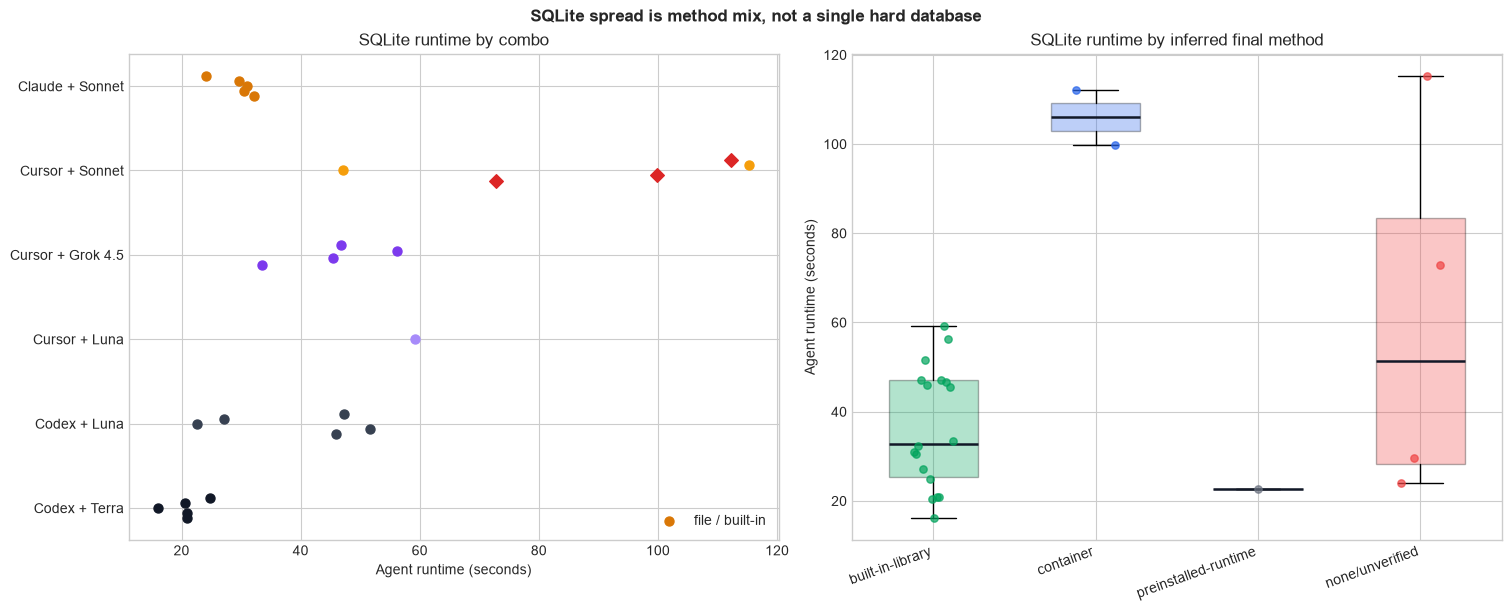

Reading: 3/25 SQLite runs used Docker (Cursor + Sonnet 3); 22 stayed on a file/built-in path. Docker-path mean 95s vs file-path mean 39s. Guard hits: 0. Pooled SQLite sd is method mix (and Cursor + Sonnet), not SQLite difficulty.


In [13]:
if not READY:
    print("Waiting for measurements.")
else:
    sqlite_runs = runs[runs["database"] == "sqlite"].copy()
    if sqlite_runs.empty:
        print("No SQLite measurement rows.")
    else:
        def _std_table(frame, group):
            stats = (
                frame.groupby(group, observed=True)
                .agg(
                    n=("runtime_s", "size"),
                    runtime_mean=("runtime_s", "mean"),
                    runtime_sd=("runtime_s", "std"),
                    runtime_min=("runtime_s", "min"),
                    runtime_max=("runtime_s", "max"),
                    cost_mean=("cost_usd", "mean"),
                    cost_sd=("cost_usd", "std"),
                    turns_mean=("num_turns", "mean"),
                    tools_mean=("tool_calls_total", "mean"),
                )
                .reset_index()
            )
            return stats.round(3)

        print("Pooled runtime/cost spread by database (finished runs only):")
        display(_std_table(runs, "database"))

        print("SQLite spread by agent/model (this is the main story):")
        sqlite_by_ext = _std_table(sqlite_runs, "extension")
        display(sqlite_by_ext)

        values = sqlite_runs["runtime_s"].dropna().to_numpy(dtype=float)
        grand_mean = float(values.mean())
        ss_total = float(((values - grand_mean) ** 2).sum())
        ss_between = 0.0
        for _, group in sqlite_runs.groupby("extension", observed=True):
            group_values = group["runtime_s"].dropna().to_numpy(dtype=float)
            if not len(group_values):
                continue
            ss_between += len(group_values) * (group_values.mean() - grand_mean) ** 2
        eta_squared = ss_between / ss_total if ss_total else np.nan
        print(
            "SQLite runtime variance decomposition: "
            f"{100 * eta_squared:.0f}% between agent/model combos, "
            f"{100 * (1 - eta_squared):.0f}% within combo "
            f"(n={len(values)}, mean={grand_mean:.1f}s, sd={values.std(ddof=1):.1f}s)."
        )

        by_mean = (
            sqlite_runs.groupby("extension", observed=True)["runtime_s"].mean().sort_values(ascending=False)
        )
        if not by_mean.empty:
            top_ext = str(by_mean.index[0])
            without_top = sqlite_runs[sqlite_runs["extension"] != top_ext]["runtime_s"]
            print(
                f"If {DISPLAY_NAMES.get(top_ext, top_ext)} (highest mean runtime) is held out, "
                f"SQLite runtime sd drops from {values.std(ddof=1):.1f}s to "
                f"{without_top.std(ddof=1):.1f}s (n={without_top.count()})."
            )

        friction_sql = f"""
        SELECT
            run_id,
            countIf(positionCaseInsensitive(payload, 'docker run') > 0) AS docker_run_hits,
            countIf(position(payload, '27017:27017') > 0 OR position(payload, '5432:5432') > 0
                 OR positionCaseInsensitive(payload, '--publish') > 0
                 OR match(payload, '-p [0-9]+:[0-9]+')) AS publish_port_hits,
            countIf(positionCaseInsensitive(payload, '--network host') > 0
                 OR positionCaseInsensitive(payload, '--network=host') > 0) AS host_network_hits,
            countIf(positionCaseInsensitive(payload, 'Docker bridge networking is unavailable') > 0) AS guard_hits,
            countIf(positionCaseInsensitive(payload, 'import sqlite3') > 0
                 OR positionCaseInsensitive(payload, 'from sqlite3') > 0) AS py_sqlite_hits,
            countIf(positionCaseInsensitive(payload, 'libsql') > 0
                 OR positionCaseInsensitive(payload, 'sqld') > 0) AS libsql_hits,
            count() AS tool_call_rows
        FROM events
        WHERE run_request_id = '{RUN_REQUEST_ID}'
          AND kind = 'tool_call'
          AND prompt_id = 'sqlite'
        GROUP BY run_id
        """
        sqlite_friction = ax_query(friction_sql)
        sqlite_detail = sqlite_runs.merge(sqlite_friction, on="run_id", how="left")
        classified = globals().get("method_runs")
        if isinstance(classified, pd.DataFrame) and not classified.empty:
            sqlite_detail = sqlite_detail.merge(
                classified[["run_id", "attempted_path", "final_method"]],
                on="run_id",
                how="left",
            )
        sqlite_detail["over_provisioned"] = sqlite_detail["docker_run_hits"].fillna(0).gt(0)

        sqlite_view = sqlite_detail[
            [
                "extension",
                "repeat_idx",
                "runtime_s",
                "cost_usd",
                "num_turns",
                "tool_calls_total",
                "both_tests_passed",
                "final_method",
                "docker_run_hits",
                "publish_port_hits",
                "host_network_hits",
                "guard_hits",
                "py_sqlite_hits",
                "libsql_hits",
            ]
        ].sort_values(["extension", "repeat_idx"])
        print("Per-run SQLite detail (boolean/count evidence only; no payloads):")
        display(sqlite_view.round(3))

        if "final_method" in sqlite_detail.columns:
            print("SQLite runtime by inferred final method:")
            display(_std_table(sqlite_detail, "final_method"))

        present_extensions = [name for name in EXTENSION_ORDER if name in set(sqlite_detail["extension"])]
        fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

        ax = axes[0]
        y_positions = np.arange(len(present_extensions))
        for y_position, extension in zip(y_positions, present_extensions):
            subset = sqlite_detail[sqlite_detail["extension"] == extension].sort_values("repeat_idx")
            jitter = np.linspace(-0.12, 0.12, len(subset)) if len(subset) > 1 else np.array([0.0])
            over = subset["over_provisioned"].to_numpy(dtype=bool)
            ax.scatter(
                subset.loc[~over, "runtime_s"],
                y_position + jitter[~over],
                color=COLORS.get(extension, "#6B7280"),
                s=42,
                zorder=3,
                label="file / built-in" if y_position == 0 else None,
            )
            if over.any():
                ax.scatter(
                    subset.loc[over, "runtime_s"],
                    y_position + jitter[over],
                    color="#DC2626",
                    marker="D",
                    s=48,
                    zorder=4,
                    label="Docker/libSQL path" if y_position == 0 else None,
                )
        ax.set_yticks(y_positions, [DISPLAY_NAMES.get(name, name) for name in present_extensions])
        ax.invert_yaxis()
        ax.set_xlabel("Agent runtime (seconds)")
        ax.set_title("SQLite runtime by combo")
        ax.legend(frameon=False, loc="lower right")

        ax = axes[1]
        if "final_method" in sqlite_detail.columns:
            methods = [
                method
                for method in [
                    "built-in-library",
                    "container",
                    "language-package-runtime",
                    "os-package-manager",
                    "preinstalled-runtime",
                    "none/unverified",
                ]
                if method in set(sqlite_detail["final_method"].fillna("unknown"))
            ]
            distributions = [
                sqlite_detail.loc[sqlite_detail["final_method"] == method, "runtime_s"].dropna().to_numpy(dtype=float)
                for method in methods
            ]
            boxes = ax.boxplot(
                distributions,
                positions=np.arange(len(methods)),
                widths=0.55,
                patch_artist=True,
                showfliers=False,
                medianprops={"color": "#111827", "linewidth": 1.8},
            )
            method_colors = {
                "container": "#2563EB",
                "os-package-manager": "#F59E0B",
                "language-package-runtime": "#7C3AED",
                "built-in-library": "#00A35C",
                "preinstalled-runtime": "#6B7280",
                "none/unverified": "#EF4444",
            }
            for patch, method in zip(boxes["boxes"], methods):
                patch.set_facecolor(method_colors.get(method, "#9CA3AF"))
                patch.set_alpha(0.30)
            for position, method, values in zip(np.arange(len(methods)), methods, distributions):
                jitter = np.linspace(-0.12, 0.12, len(values)) if len(values) > 1 else np.array([0.0])
                ax.scatter(position + jitter, values, color=method_colors.get(method, "#6B7280"), s=28, alpha=0.7, zorder=3)
            ax.set_xticks(np.arange(len(methods)), methods, rotation=20, ha="right")
        ax.set_ylabel("Agent runtime (seconds)")
        ax.set_title("SQLite runtime by inferred final method")
        fig.suptitle("SQLite spread is method mix, not a single hard database", fontweight="bold")
        plt.show()

        n_over = int(sqlite_detail["over_provisioned"].fillna(False).sum())
        n_file = int((~sqlite_detail["over_provisioned"].fillna(False)).sum())
        n_guard = int(sqlite_detail["guard_hits"].fillna(0).gt(0).sum())
        docker_by_ext = (
            sqlite_detail.groupby("extension", observed=True)["over_provisioned"].sum()
        )
        docker_by_ext = docker_by_ext[docker_by_ext.fillna(0).gt(0)]
        docker_label = ", ".join(
            f"{DISPLAY_NAMES.get(name, name)} {int(count)}"
            for name, count in docker_by_ext.items()
        )
        file_runtime = sqlite_detail.loc[~sqlite_detail["over_provisioned"].fillna(False), "runtime_s"]
        docker_runtime = sqlite_detail.loc[sqlite_detail["over_provisioned"].fillna(False), "runtime_s"]
        print(
            f"Reading: {n_over}/{len(sqlite_detail)} SQLite runs used Docker"
            + (f" ({docker_label})" if docker_label else "")
            + f"; {n_file} stayed on a file/built-in path. "
            + (
                f"Docker-path mean {docker_runtime.mean():.0f}s vs file-path mean {file_runtime.mean():.0f}s. "
                if docker_runtime.notna().any() and file_runtime.notna().any()
                else ""
            )
            + (
                f"Guard hits: {n_guard}. Pooled SQLite sd is method mix "
                f"(and {DISPLAY_NAMES.get(top_ext, top_ext)}), "
                "not SQLite difficulty."
                if "top_ext" in locals()
                else f"Guard hits: {n_guard}. Pooled SQLite sd is method mix, not SQLite difficulty."
            )
        )


## MongoDB provision friction and outliers

Platform Docker worked. All **30/30** MongoDB trials used `docker run -p`.
**Guard hits: 0/30.** Leftover `--network host`: **1/30** (Claude + Sonnet;
habit, not the old wrapper).

Both-tests pass: **29/30**. The miss is Cursor + Grok repeat 4: the verifier
saw readiness/TCP only, not an application-level MongoDB operation.

Runtime mean **50.5s, sd 15.3s**. That is much tighter than the guarded
docker-host n=5, where every trial paid a host-network retry. Remaining
friction is image pull / wait-for-ready and extra `docker run`, concentrated
in Cursor + Luna (mean 71s, sd 20s).

Outliers below are |z| ≥ 2 on runtime or cost among finished MongoDB rows:

- Cursor + Luna r0 (~98s): extra `docker run` / missing-image / mongosh hits; still passed.
- Cursor + Luna r3 (~89s): only 2 turns — wait, not extra work.
- Claude r0 and Cursor + Sonnet r2: **cost** outliers (~$0.26–$0.27) from token volume, not Docker recovery.


MongoDB finished runs: 30; both-tests pass: 29/30; docker run: 30/30; published -p: 30/30; guard hit: 0/30; --network host: 1/30.
MongoDB runtime mean 50.5s, sd 15.3s. Without the slowest run: mean 48.9s, sd 12.7s.
Outliers (|z| >= 2 on runtime or cost):


,extension,repeat_idx,runtime_s,runtime_z,cost_usd,cost_z,num_turns,tool_calls_total,docker_run_hits,publish_port_hits,host_network_hits,guard_hits,missing_image_hits,apt_mongo_hits,mongosh_hits,both_tests_passed
20,cursor-luna,0,97.547,3.067,0.168,0.770,4,19.0,8,8,0,0,3,2,8,True
23,cursor-luna,3,88.943,2.506,0.055,-0.953,2,4.0,2,2,0,0,1,0,2,True
0,claude-sonnet,0,74.650,1.574,0.263,2.226,11,10.0,6,6,0,0,2,2,10,True
17,cursor-sonnet,2,65.851,1.000,0.272,2.358,4,7.0,2,2,0,0,1,0,4,True


MongoDB friction flags by agent/model:


,extension,n,runtime_mean,runtime_sd,cost_mean,cost_sd,publish_share,host_share,guard_share,docker_run_mean,apt_mongo_mean
0,claude-sonnet,5,52.303,12.763,0.182,0.055,1.0,0.2,0.0,4.0,1.6
1,cursor-sonnet,5,56.054,9.286,0.184,0.060,1.0,0.0,0.0,2.0,0.6
2,cursor-grok,5,43.349,2.556,0.134,0.014,1.0,0.0,0.0,2.0,0.4
3,cursor-luna,5,71.272,20.428,0.102,0.041,1.0,0.0,0.0,4.4,0.4
4,codex-luna,5,40.740,4.359,0.052,0.008,1.0,0.0,0.0,2.0,0.0
5,codex-terra,5,39.365,9.646,0.049,0.009,1.0,0.0,0.0,2.0,0.0


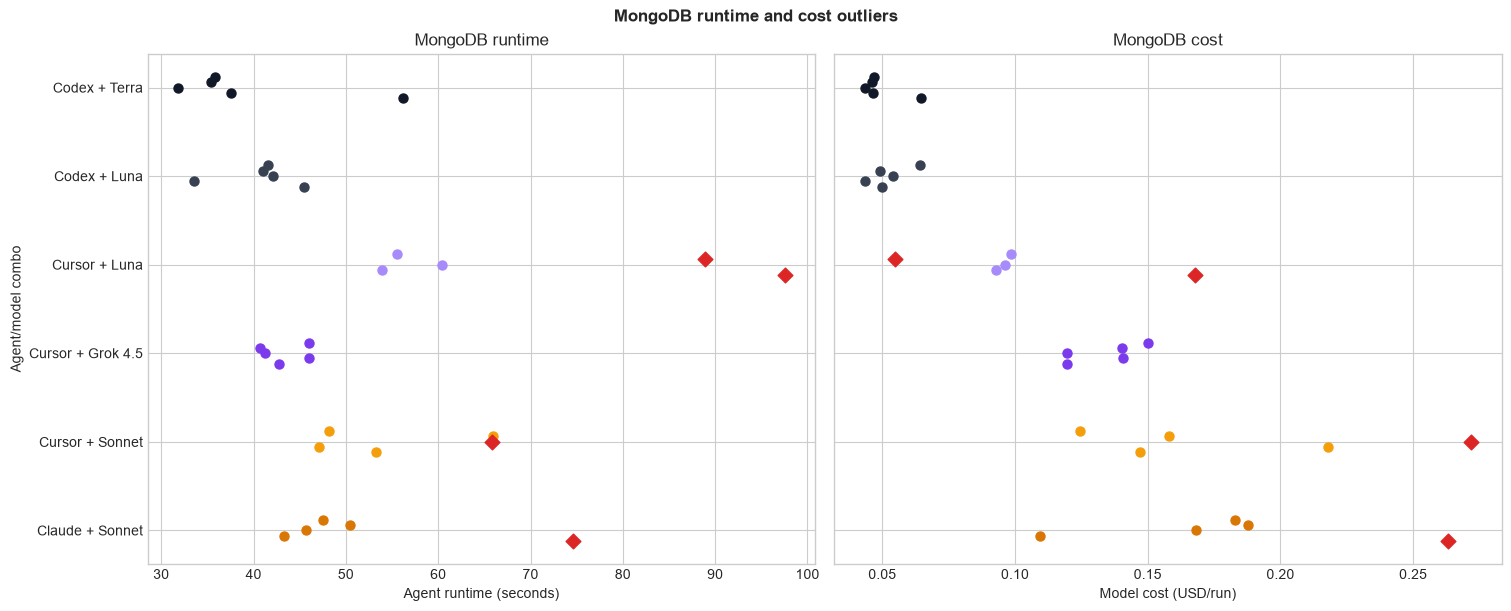

Reading: platform Docker is working (published -p 30/30, guard 0/30). Leftover --network host: 1/30. Cursor + Luna is the remaining runtime tail (n=5, mean 71s, sd 20s); that is wait / extra docker run, not a networking wrapper.


In [14]:
if not READY:
    print("Waiting for measurements.")
else:
    mongo_runs = runs[runs["database"] == "mongodb"].copy()
    if mongo_runs.empty:
        print("No MongoDB measurement rows.")
    else:
        mongo_sql = f"""
        SELECT
            run_id,
            countIf(positionCaseInsensitive(payload, 'docker run') > 0) AS docker_run_hits,
            countIf(position(payload, '27017:27017') > 0
                 OR positionCaseInsensitive(payload, '--publish') > 0
                 OR match(payload, '-p [0-9]+:[0-9]+')) AS publish_port_hits,
            countIf(positionCaseInsensitive(payload, '--network host') > 0
                 OR positionCaseInsensitive(payload, '--network=host') > 0) AS host_network_hits,
            countIf(positionCaseInsensitive(payload, 'Docker bridge networking is unavailable') > 0) AS guard_hits,
            countIf(positionCaseInsensitive(payload, 'Unable to find image') > 0) AS missing_image_hits,
            countIf(positionCaseInsensitive(payload, 'docker pull') > 0) AS docker_pull_hits,
            countIf(positionCaseInsensitive(payload, 'apt') > 0
                 AND positionCaseInsensitive(payload, 'mongo') > 0) AS apt_mongo_hits,
            countIf(positionCaseInsensitive(payload, 'mongosh') > 0) AS mongosh_hits,
            count() AS tool_call_rows
        FROM events
        WHERE run_request_id = '{RUN_REQUEST_ID}'
          AND kind = 'tool_call'
          AND prompt_id = 'mongodb'
        GROUP BY run_id
        """
        mongo_friction = ax_query(mongo_sql)
        mongo_detail = mongo_runs.merge(mongo_friction, on="run_id", how="left")
        classified = globals().get("method_runs")
        if isinstance(classified, pd.DataFrame) and not classified.empty:
            mongo_detail = mongo_detail.merge(
                classified[["run_id", "attempted_path", "final_method"]],
                on="run_id",
                how="left",
            )

        n_mongo = len(mongo_detail)
        n_pass = int(mongo_detail["both_tests_passed"].sum())
        n_guard = int(mongo_detail["guard_hits"].fillna(0).gt(0).sum())
        n_host = int(mongo_detail["host_network_hits"].fillna(0).gt(0).sum())
        n_publish = int(mongo_detail["publish_port_hits"].fillna(0).gt(0).sum())
        n_docker = int(mongo_detail["docker_run_hits"].fillna(0).gt(0).sum())
        print(
            f"MongoDB finished runs: {n_mongo}; both-tests pass: {n_pass}/{n_mongo}; "
            f"docker run: {n_docker}/{n_mongo}; published -p: {n_publish}/{n_mongo}; "
            f"guard hit: {n_guard}/{n_mongo}; --network host: {n_host}/{n_mongo}."
        )

        runtime_mean = mongo_detail["runtime_s"].mean()
        runtime_sd = mongo_detail["runtime_s"].std(ddof=1)
        cost_mean = mongo_detail["cost_usd"].mean()
        cost_sd = mongo_detail["cost_usd"].std(ddof=1)
        if mongo_detail["runtime_s"].notna().any():
            drop_idx = mongo_detail["runtime_s"].idxmax()
            without_max = mongo_detail.drop(index=drop_idx)["runtime_s"]
            print(
                f"MongoDB runtime mean {runtime_mean:.1f}s, sd {runtime_sd:.1f}s. "
                f"Without the slowest run: mean {without_max.mean():.1f}s, "
                f"sd {without_max.std(ddof=1):.1f}s."
            )
        else:
            print(f"MongoDB runtime mean {runtime_mean:.1f}s, sd {runtime_sd:.1f}s.")

        mongo_detail["runtime_z"] = (mongo_detail["runtime_s"] - runtime_mean) / runtime_sd
        mongo_detail["cost_z"] = (mongo_detail["cost_usd"] - cost_mean) / cost_sd
        outliers = mongo_detail[
            (mongo_detail["runtime_z"].abs() >= 2) | (mongo_detail["cost_z"].abs() >= 2)
        ].copy()
        print("Outliers (|z| >= 2 on runtime or cost):")
        display(
            outliers[
                [
                    "extension",
                    "repeat_idx",
                    "runtime_s",
                    "runtime_z",
                    "cost_usd",
                    "cost_z",
                    "num_turns",
                    "tool_calls_total",
                    "docker_run_hits",
                    "publish_port_hits",
                    "host_network_hits",
                    "guard_hits",
                    "missing_image_hits",
                    "apt_mongo_hits",
                    "mongosh_hits",
                    "both_tests_passed",
                ]
            ]
            .sort_values("runtime_s", ascending=False)
            .round(3)
        )

        print("MongoDB friction flags by agent/model:")
        friction_summary = (
            mongo_detail.groupby("extension", observed=True)
            .agg(
                n=("run_id", "size"),
                runtime_mean=("runtime_s", "mean"),
                runtime_sd=("runtime_s", "std"),
                cost_mean=("cost_usd", "mean"),
                cost_sd=("cost_usd", "std"),
                publish_share=("publish_port_hits", lambda s: s.fillna(0).gt(0).mean()),
                host_share=("host_network_hits", lambda s: s.fillna(0).gt(0).mean()),
                guard_share=("guard_hits", lambda s: s.fillna(0).gt(0).mean()),
                docker_run_mean=("docker_run_hits", "mean"),
                apt_mongo_mean=("apt_mongo_hits", "mean"),
            )
            .reset_index()
            .round(3)
        )
        display(friction_summary)

        present_extensions = [name for name in EXTENSION_ORDER if name in set(mongo_detail["extension"])]
        fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True, constrained_layout=True)
        y_positions = np.arange(len(present_extensions))
        outlier_ids = set(outliers["run_id"])

        for ax, metric, xlabel, title in [
            (axes[0], "runtime_s", "Agent runtime (seconds)", "MongoDB runtime"),
            (axes[1], "cost_usd", "Model cost (USD/run)", "MongoDB cost"),
        ]:
            for y_position, extension in zip(y_positions, present_extensions):
                subset = mongo_detail[mongo_detail["extension"] == extension].sort_values("repeat_idx")
                jitter = np.linspace(-0.12, 0.12, len(subset)) if len(subset) > 1 else np.array([0.0])
                is_outlier = subset["run_id"].isin(outlier_ids).to_numpy(dtype=bool)
                ax.scatter(
                    subset.loc[~is_outlier, metric],
                    y_position + jitter[~is_outlier],
                    color=COLORS.get(extension, "#6B7280"),
                    s=42,
                    zorder=3,
                )
                if is_outlier.any():
                    ax.scatter(
                        subset.loc[is_outlier, metric],
                        y_position + jitter[is_outlier],
                        color="#DC2626",
                        marker="D",
                        s=56,
                        zorder=4,
                    )
            ax.set_yticks(y_positions, [DISPLAY_NAMES.get(name, name) for name in present_extensions])
            ax.invert_yaxis()
            ax.set_xlabel(xlabel)
            ax.set_title(title)
        axes[0].set_ylabel("Agent/model combo")
        fig.suptitle("MongoDB runtime and cost outliers", fontweight="bold")
        plt.show()

        luna = mongo_detail[mongo_detail["extension"] == "cursor-luna"]["runtime_s"]
        print(
            f"Reading: platform Docker is working "
            f"(published -p {n_publish}/{n_mongo}, guard {n_guard}/{n_mongo}). "
            f"Leftover --network host: {n_host}/{n_mongo}. "
            f"Cursor + Luna is the remaining runtime tail "
            f"(n={luna.count()}, mean {luna.mean():.0f}s, sd {luna.std(ddof=1):.0f}s); "
            "that is wait / extra docker run, not a networking wrapper."
        )


## PostgreSQL is the completion gap

MongoDB is near-ceiling on this request. PostgreSQL is not: **21/30** both-tests
pass. Cursor + Grok and Cursor + Luna are 2/5, all `connection-verified-in-agent`
with readiness-only evidence. Claude is 5/5. Codex is 4/5. Cursor + Sonnet is
4/5 measured plus one `model_unsupported_by_harness` error.

Docker is not the blocker: **28/30** published `-p`, **0** guard hits. The two
leftover `--network host` runs are habit.

Pooled Postgres runtime sd (~28s) looks as wide as SQLite because of **one
Cursor + Sonnet trial at 177s**. That trial passed via `os-package-manager`
(apt + many `psql` hits, no `-p`), not Docker. Treat it as an efficiency
outlier, not method mix.


In [15]:
if not READY:
    print("Waiting for measurements.")
else:
    pg_runs = runs[runs["database"] == "postgresql"].copy()
    if pg_runs.empty:
        print("No PostgreSQL measurement rows.")
    else:
        pg_sql = f"""
        SELECT
            run_id,
            countIf(positionCaseInsensitive(payload, 'docker run') > 0) AS docker_run_hits,
            countIf(position(payload, '5432:5432') > 0
                 OR positionCaseInsensitive(payload, '--publish') > 0
                 OR match(payload, '-p [0-9]+:[0-9]+')) AS publish_port_hits,
            countIf(positionCaseInsensitive(payload, '--network host') > 0
                 OR positionCaseInsensitive(payload, '--network=host') > 0) AS host_network_hits,
            countIf(positionCaseInsensitive(payload, 'Docker bridge networking is unavailable') > 0) AS guard_hits,
            countIf(positionCaseInsensitive(payload, 'pg_isready') > 0) AS pg_isready_hits,
            countIf(positionCaseInsensitive(payload, 'psql') > 0) AS psql_hits,
            count() AS tool_call_rows
        FROM events
        WHERE run_request_id = '{RUN_REQUEST_ID}'
          AND kind = 'tool_call'
          AND prompt_id = 'postgresql'
        GROUP BY run_id
        """
        pg_friction = ax_query(pg_sql)
        pg_detail = pg_runs.merge(pg_friction, on="run_id", how="left")
        classified = globals().get("method_runs")
        if isinstance(classified, pd.DataFrame) and not classified.empty:
            pg_detail = pg_detail.merge(
                classified[["run_id", "attempted_path", "final_method"]],
                on="run_id",
                how="left",
            )

        n_pg = len(pg_detail)
        n_pass = int(pg_detail["both_tests_passed"].sum())
        n_publish = int(pg_detail["publish_port_hits"].fillna(0).gt(0).sum())
        n_host = int(pg_detail["host_network_hits"].fillna(0).gt(0).sum())
        n_guard = int(pg_detail["guard_hits"].fillna(0).gt(0).sum())
        print(
            f"PostgreSQL finished runs: {n_pg}; both-tests pass: {n_pass}/{n_pg}; "
            f"published -p: {n_publish}/{n_pg}; guard: {n_guard}/{n_pg}; "
            f"--network host: {n_host}/{n_pg}."
        )

        by_ext = (
            pg_detail.groupby("extension", observed=True)
            .agg(
                n=("run_id", "size"),
                passed=("both_tests_passed", "sum"),
                runtime_mean=("runtime_s", "mean"),
                runtime_max=("runtime_s", "max"),
                cost_mean=("cost_usd", "mean"),
                publish_share=("publish_port_hits", lambda s: s.fillna(0).gt(0).mean()),
                pg_isready_share=("pg_isready_hits", lambda s: s.fillna(0).gt(0).mean()),
                psql_share=("psql_hits", lambda s: s.fillna(0).gt(0).mean()),
            )
            .reset_index()
        )
        by_ext["pass_pct"] = 100 * by_ext["passed"] / by_ext["n"]
        display(by_ext.round(3))

        if "final_method" in pg_detail.columns:
            print("PostgreSQL inferred final method:")
            display(
                pg_detail.groupby(["extension", "final_method"], observed=True)
                .size()
                .rename("n")
                .reset_index()
            )

        runtime_mean = pg_detail["runtime_s"].mean()
        runtime_sd = pg_detail["runtime_s"].std(ddof=1)
        cost_mean = pg_detail["cost_usd"].mean()
        cost_sd = pg_detail["cost_usd"].std(ddof=1)
        pg_detail["runtime_z"] = (pg_detail["runtime_s"] - runtime_mean) / runtime_sd
        pg_detail["cost_z"] = (pg_detail["cost_usd"] - cost_mean) / cost_sd
        outliers = pg_detail[
            (pg_detail["runtime_z"].abs() >= 2) | (pg_detail["cost_z"].abs() >= 2)
        ].copy()
        print("Outliers (|z| >= 2 on runtime or cost):")
        display(
            outliers[
                [
                    "extension",
                    "repeat_idx",
                    "runtime_s",
                    "runtime_z",
                    "cost_usd",
                    "cost_z",
                    "num_turns",
                    "both_tests_passed",
                    "final_method",
                    "publish_port_hits",
                    "host_network_hits",
                    "pg_isready_hits",
                    "psql_hits",
                ]
            ]
            .sort_values("runtime_s", ascending=False)
            .round(3)
        )

        if "failures" in globals() and isinstance(failures, pd.DataFrame) and not failures.empty:
            pg_fails = failures[failures["database"] == "postgresql"]
            if not pg_fails.empty:
                print("PostgreSQL official-test misses:")
                display(
                    pg_fails.groupby(["extension", "test_name", "failure_mode"], observed=True)
                    .size()
                    .rename("n")
                    .reset_index()
                )

        print(
            f"Reading: Postgres completion is the gap ({n_pass}/{n_pg} both-tests), "
            f"not Docker ({n_publish}/{n_pg} published -p, {n_guard} guard hits). "
            "Readiness-only verifier misses concentrate on Cursor + Grok / Luna. "
            "The pooled runtime sd is a Cursor + Sonnet tail, not method mix."
        )


PostgreSQL finished runs: 30; both-tests pass: 21/30; published -p: 28/30; guard: 0/30; --network host: 2/30.


,extension,n,passed,runtime_mean,runtime_max,cost_mean,publish_share,pg_isready_share,psql_share,pass_pct
0,claude-sonnet,5,5,36.895,42.014,0.119,1.0,1.0,1.0,100.0
1,cursor-sonnet,5,4,65.030,177.373,0.306,0.6,0.6,0.8,80.0
2,cursor-grok,5,2,34.849,42.162,0.117,1.0,1.0,1.0,40.0
3,cursor-luna,5,2,55.020,74.497,0.073,1.0,1.0,1.0,40.0
4,codex-luna,5,4,35.700,41.635,0.050,1.0,1.0,0.8,80.0
5,codex-terra,5,4,38.883,52.509,0.052,1.0,1.0,1.0,80.0


PostgreSQL inferred final method:


,extension,final_method,n
0,claude-sonnet,container,5
1,cursor-sonnet,container,3
2,cursor-sonnet,none/unverified,1
3,cursor-sonnet,os-package-manager,1
4,cursor-grok,container,2
5,cursor-grok,none/unverified,3
6,cursor-luna,container,2
7,cursor-luna,none/unverified,3
8,codex-luna,container,4
9,codex-luna,none/unverified,1


Outliers (|z| >= 2 on runtime or cost):


,extension,repeat_idx,runtime_s,runtime_z,cost_usd,cost_z,num_turns,both_tests_passed,final_method,publish_port_hits,host_network_hits,pg_isready_hits,psql_hits
19,cursor-sonnet,4,177.373,4.819,0.739,4.912,8,True,os-package-manager,0.0,0.0,0.0,14.0


PostgreSQL official-test misses:


,extension,test_name,failure_mode,n
0,cursor-grok,connection-verified-in-agent,readiness-only,3
1,cursor-luna,connection-verified-in-agent,readiness-only,3
2,codex-luna,connection-verified-in-agent,readiness-only,1
3,codex-terra,connection-verified-in-agent,readiness-only,1


Reading: Postgres completion is the gap (21/30 both-tests), not Docker (28/30 published -p, 0 guard hits). Readiness-only verifier misses concentrate on Cursor + Grok / Luna. The pooled runtime sd is a Cursor + Sonnet tail, not method mix.


## Interpretation

Computed on request `01KZXQNVBT2EYND880NRVHR7BY` with **85/90** finished
measurement rows ($10.43, mean $0.124/run). Still outstanding at execute time:
four Cursor + Luna / SQLite trials (starvation risk) and one Cursor + Grok /
SQLite trial. One Cursor + Sonnet / PostgreSQL trial failed before provisioning
(`model_unsupported_by_harness`: Cursor rejected `claude-sonnet-5`).

### Docker contract vs the guarded n=5

The old guard is gone. Across finished runs: **0/85 guard hits**. MongoDB
30/30 published `-p`; PostgreSQL 28/30; SQLite 3/25 (over-provisioned file DB).
Leftover `--network host` is rare (Mongo 1, Postgres 2). Agents are using
ordinary bridge publish, not the host-network retry loop.

### Completion

Overall both-tests pass on finished rows: **83.5%** (71/85).

- **MongoDB is near-ceiling** (29/30). The one miss is a verifier
  readiness-only fail, not a Docker networking fail.
- **PostgreSQL is the completion gap.** Cursor + Grok and Cursor + Luna are
  2/5; most of those fails are `connection-verified-in-agent` with
  readiness-only (`pg_isready` / TCP) evidence. Claude is 5/5. Codex is 4/5.
- **SQLite is not uniformly easy on the official tests.** Claude 3/5
  (`uri-reported` misses despite `sqlite3`). Cursor + Sonnet 3/5
  (`connection-verified` misses, including Docker/libSQL paths). Codex is 5/5.

Pooled Postgres runtime sd (27.6s) looks as wide as SQLite because of a
Cursor + Sonnet tail (one passing trial at 177s), not because Postgres is
method-mixed the way SQLite is.

### PostgreSQL completion

The interesting ranking question on this n=5 is **Postgres vs Mongo**, not
stock vs Docker. Cursor + Grok / Luna fail `connection-verified-in-agent` on
readiness-only evidence (8 of 9 Postgres test misses are that mode). That is a
verifier/agent-behavior issue, not a missing Docker runtime. The 177s Cursor +
Sonnet trial passed on an apt/`psql` path (`os-package-manager`), not Docker;
treat it as an efficiency outlier.

### SQLite spread

Do not read pooled SQLite sd=28s as “SQLite is hard.” **77% of variance is
between harnesses.** Cursor + Sonnet paid a container/libSQL tax (~100s+);
Codex + Terra / Claude stayed on file `sqlite3` (~17–32s). Hold out Cursor +
Sonnet and sd falls to 13s.

### MongoDB friction

No guard tax. The remaining Mongo story is **Cursor + Luna wait / extra
docker run** (two runtime outliers, both still passed) and **token-volume
cost spikes** on Claude / Cursor + Sonnet, not networking recovery.

### Pruning

Do **not** prune either same-model harness pair from n=5:

- **Sonnet, Claude vs Cursor:** Mongo completion matches (5/5), but Cursor is
  ~2–4× the cost on Postgres and SQLite, 3× slower on SQLite, and Cursor
  Postgres has a 177s passing outlier plus a harness model-id error.
- **Luna, Codex vs Cursor:** Mongo completion matches, but Cursor Postgres is
  2/5 vs Codex 4/5, Cursor is ~2× the cost, and Cursor SQLite is almost
  entirely unmeasured (1/5 rows).

Wide Wilson intervals on n=5 are not evidence of equivalence.

### Scale recommendation

Keep the default **n=20 per retained variant** if the question is still
completion (Postgres gap, SQLite test misses). If Mongo stays near-ceiling and
the remaining question is efficiency among successes, n=10 is enough for
cost/runtime CIs. Working cost if both duplicate harnesses were dropped:
4 combos × 3 DBs × n=20 ≈ **$23** ($26 with 15% contingency). With all six
combos at n=20: ≈ **$45**.
